In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 69.6 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [2]:
import os
import cv2
import yaml
import time
import torch
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
print("PyTorch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name :", torch.cuda.get_device_name(0))
    print("GPU Count :", torch.cuda.device_count())
else:
    print("Running on CPU")

PyTorch Version : 2.10.0+cu128
CUDA Available : True
GPU Name : Tesla T4
GPU Count : 2


In [5]:
DATASET_PATH = "/kaggle/input/datasets/tanya24jain/indian-vehicle-detection-dataset-for-yolov8"

IMAGE_PATH = os.path.join(DATASET_PATH,"train/images")
LABEL_PATH = os.path.join(DATASET_PATH,"train/labels")
YAML_PATH = os.path.join(DATASET_PATH,"data.yaml")
print(DATASET_PATH)

/kaggle/input/datasets/tanya24jain/indian-vehicle-detection-dataset-for-yolov8


In [6]:
for root, dirs, files in os.walk(DATASET_PATH):

    print(f"\n {root}")

    for file in files[:10]:
        print("   ",file)



 /kaggle/input/datasets/tanya24jain/indian-vehicle-detection-dataset-for-yolov8
    README.roboflow.txt
    data.yaml

 /kaggle/input/datasets/tanya24jain/indian-vehicle-detection-dataset-for-yolov8/train

 /kaggle/input/datasets/tanya24jain/indian-vehicle-detection-dataset-for-yolov8/train/labels
    Truck_1438_jpg.rf.bb2221305a2be94aa74e876cdab8ff15.txt
    Truck_3221_jpg.rf.6a24cc419b1d78b70a0b5c9821652607.txt
    Truck_2886_jpg.rf.262ed7bbb12c1a7fdfe3711b1d390dae.txt
    Car_6406_jpg.rf.3b19eb551e1d3e86450836921dea718b.txt
    Truck_2406_jpg.rf.ac7db1e29561e0fd387b615a607c035b.txt
    Auto-rickshaw_765_jpg.rf.d9d47c7c924d08b2f45eee48a7145984.txt
    Car_1839_jpg.rf.5109400d9cf6ec06fbe12c8afee6e484.txt
    Auto-rickshaw_2975_jpg.rf.909965ff0f1ecf6a3d66e6b31d58863e.txt
    Auto-rickshaw_1346_jpg.rf.1630af1223f07ebb6652f1b11f3442b8.txt
    Car_3272_jpg.rf.61d01af4dea07d2d57b6c5f362d0d877.txt

 /kaggle/input/datasets/tanya24jain/indian-vehicle-detection-dataset-for-yolov8/train/images

In [7]:
with open(YAML_PATH,'r') as f:
    data_yaml = yaml.safe_load(f)

print("YAML CONTENT")
print("-"*50)

for key,value in data_yaml.items():
    print(f"{key} : {value}")

YAML CONTENT
--------------------------------------------------
train : ../train/images
val : ../valid/images
test : ../test/images
nc : 5
names : ['autorickshaw', 'bike', 'bus', 'car', 'truck']
roboflow : {'workspace': 'tanyas-workspace-rrytc', 'project': 'indian-traffic-vehicle-detection', 'version': 1, 'license': 'Private', 'url': 'https://app.roboflow.com/tanyas-workspace-rrytc/indian-traffic-vehicle-detection/1'}


In [8]:
class_names = data_yaml['names']

for idx,name in enumerate(class_names):
    print(f"Class {idx} : {name}")
    
print("Total Classes :", len(class_names))

Class 0 : autorickshaw
Class 1 : bike
Class 2 : bus
Class 3 : car
Class 4 : truck
Total Classes : 5


In [9]:
total_images = len(os.listdir(IMAGE_PATH))
total_labels = len(os.listdir(LABEL_PATH))

print("Total Images :", total_images)
print("Total Labels :", total_labels)

Total Images : 3852
Total Labels : 3852


In [32]:
from collections import Counter

counter = Counter()

for file in os.listdir(LABEL_PATH):

    with open(os.path.join(LABEL_PATH,file)) as f:

        lines = f.readlines()

        for line in lines:

            cls = int(line.split()[0])

            counter[cls] += 1

for cls,count in sorted(counter.items()):
    print(f"{class_names[cls]:15s} : {count}")


Autorickshaw    : 825
Bike            : 1113
Bus             : 761
Car             : 1774
Truck           : 881


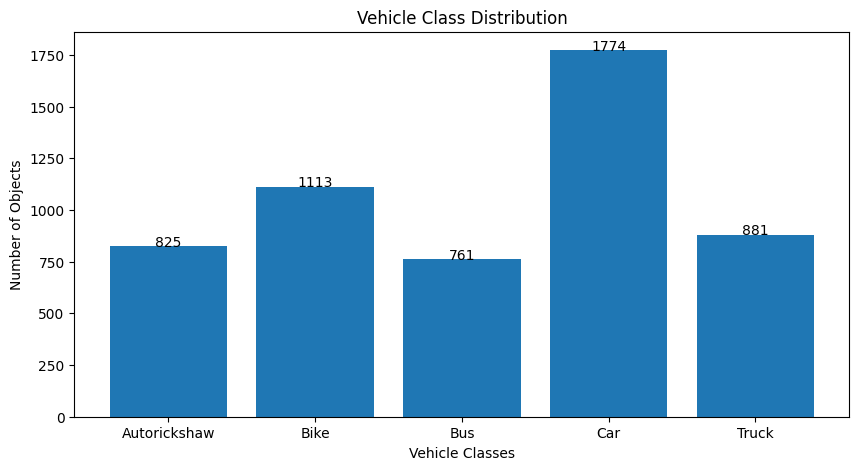

In [33]:
import matplotlib.pyplot as plt

names = []
counts = []

for cls,count in sorted(counter.items()):
    names.append(class_names[cls])
    counts.append(count)

plt.figure(figsize=(10,5))

bars = plt.bar(names, counts)

plt.title("Vehicle Class Distribution")
plt.xlabel("Vehicle Classes")
plt.ylabel("Number of Objects")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y,
        int(y),
        ha='center'
    )

plt.show()

In [34]:
image_files = {
    os.path.splitext(f)[0]
    for f in os.listdir(IMAGE_PATH)
}

label_files = {
    os.path.splitext(f)[0]
    for f in os.listdir(LABEL_PATH)
}

missing_labels = image_files - label_files

print("Total Images :", len(image_files))
print("Total Labels :", len(label_files))
print("Missing Labels :", len(missing_labels))

if len(missing_labels) > 0:
    print("\nExamples:")
    print(list(missing_labels)[:10])

Total Images : 3852
Total Labels : 3852
Missing Labels : 0


In [35]:
empty_files = []

for file in os.listdir(LABEL_PATH):

    path = os.path.join(LABEL_PATH,file)

    if os.path.getsize(path) == 0:
        empty_files.append(file)

print("Empty Label Files :", len(empty_files))

if len(empty_files) > 0:
    print(empty_files[:10])

Empty Label Files : 4
['Car_8060_jpg.rf.11ee00d3637279d2f5525523c65556c1.txt', 'Bus_2451_jpg.rf.bd01808eddaf679a9c636abc0538e2b4.txt', 'Bus_2488_jpg.rf.da782eba377a45745db9d0b547f20d7f.txt', 'Truck_58_jpg.rf.f6ee01b26a2344016012a25bde583fbe.txt']


In [36]:
valid_classes = [0,1,2,3,4]

invalid_annotations = []

for file in os.listdir(LABEL_PATH):

    path = os.path.join(LABEL_PATH,file)

    with open(path,"r") as f:

        lines = f.readlines()

    for line in lines:

        cls = int(line.split()[0])

        if cls not in valid_classes:
            invalid_annotations.append(file)

print("Invalid Annotation Files :", len(invalid_annotations))

if len(invalid_annotations)>0:
    print(invalid_annotations[:10])


Invalid Annotation Files : 0


In [37]:
from PIL import Image

corrupted = []

for img in os.listdir(IMAGE_PATH):

    try:
        path = os.path.join(IMAGE_PATH,img)

        Image.open(path).verify()

    except:
        corrupted.append(img)

print("Corrupted Images :", len(corrupted))

if len(corrupted)>0:
    print(corrupted[:10])


Corrupted Images : 0


In [38]:
widths = []
heights = []

sample_images = os.listdir(IMAGE_PATH)

for img_name in sample_images:

    img = cv2.imread(
        os.path.join(IMAGE_PATH,img_name)
    )

    h,w = img.shape[:2]

    heights.append(h)
    widths.append(w)

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))

print("Average Width :", round(np.mean(widths),2))
print("Average Height :", round(np.mean(heights),2))

Minimum Width : 512
Maximum Width : 512
Minimum Height : 512
Maximum Height : 512
Average Width : 512.0
Average Height : 512.0


In [39]:
import matplotlib.pyplot as plt

empty_images = []

for file in empty_files:

    image_name = file.replace(".txt",".jpg")

    jpg_path = os.path.join(IMAGE_PATH,image_name)

    png_path = os.path.join(
        IMAGE_PATH,
        image_name.replace(".jpg",".png")
    )

    if os.path.exists(jpg_path):
        empty_images.append(jpg_path)

    elif os.path.exists(png_path):
        empty_images.append(png_path)

print("Empty Label Images Found:",len(empty_images))

Empty Label Images Found: 4


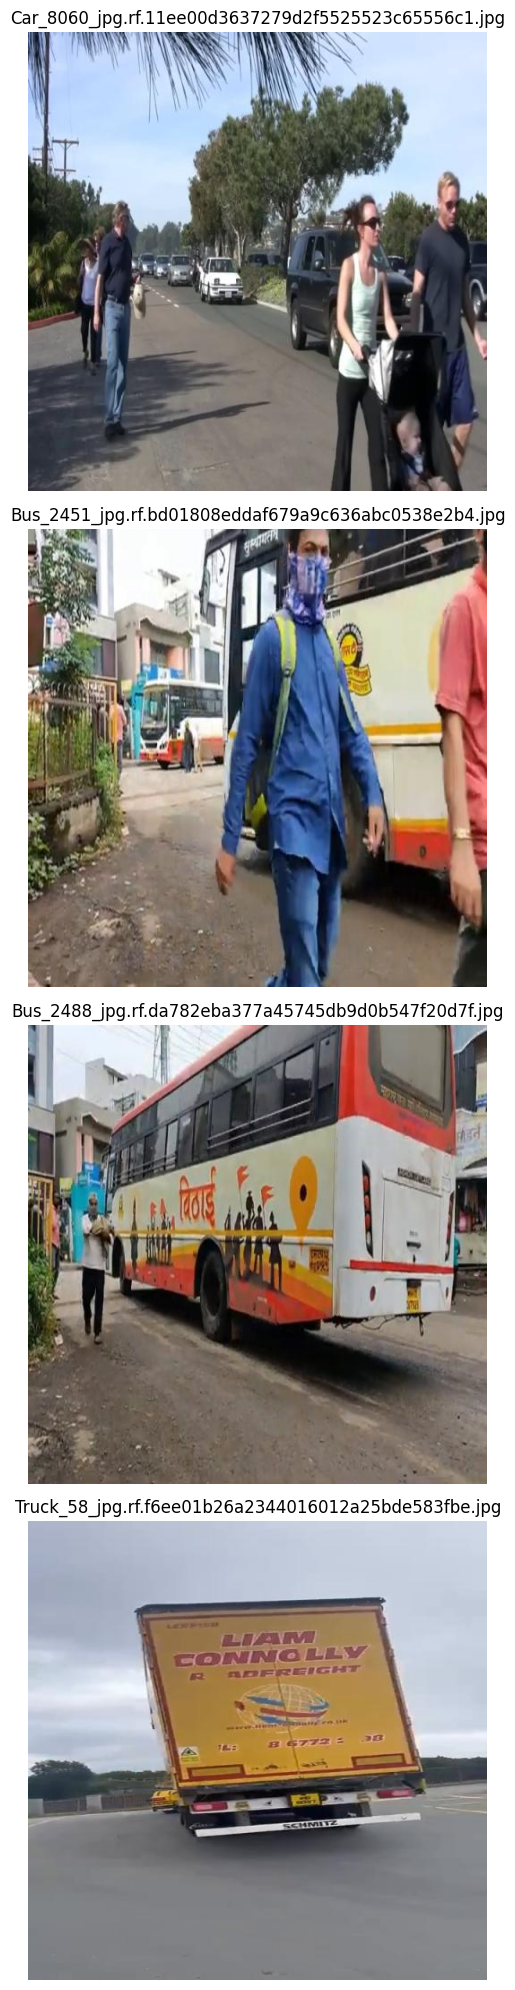

In [40]:
fig, axes = plt.subplots(
    len(empty_images),
    1,
    figsize=(10,5*len(empty_images))
)

if len(empty_images)==1:
    axes=[axes]

for ax,img_path in zip(axes,empty_images):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    ax.set_title(
        os.path.basename(img_path)
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
import shutil
import os

CLEAN_DATASET = "/kaggle/working/clean_dataset"

os.makedirs(f"{CLEAN_DATASET}/images", exist_ok=True)
os.makedirs(f"{CLEAN_DATASET}/labels", exist_ok=True)

removed_count = 0

for img_file in os.listdir(IMAGE_PATH):

    label_file = img_file.rsplit(".",1)[0] + ".txt"

    label_path = os.path.join(LABEL_PATH,label_file)

    skip = False

    if os.path.exists(label_path):

        if os.path.getsize(label_path) == 0:
            skip = True
            removed_count += 1

    if not skip:

        shutil.copy(
            os.path.join(IMAGE_PATH,img_file),
            os.path.join(CLEAN_DATASET,"images",img_file)
        )

        shutil.copy(
            label_path,
            os.path.join(CLEAN_DATASET,"labels",label_file)
        )

print("Removed Empty Annotation Samples :", removed_count)
print("Clean Dataset")

Removed Empty Annotation Samples : 4
Clean Dataset


In [42]:
clean_images = len(os.listdir(f"{CLEAN_DATASET}/images"))
clean_labels = len(os.listdir(f"{CLEAN_DATASET}/labels"))

print("Clean Images :", clean_images)
print("Clean Labels :", clean_labels)

Clean Images : 3848
Clean Labels : 3848


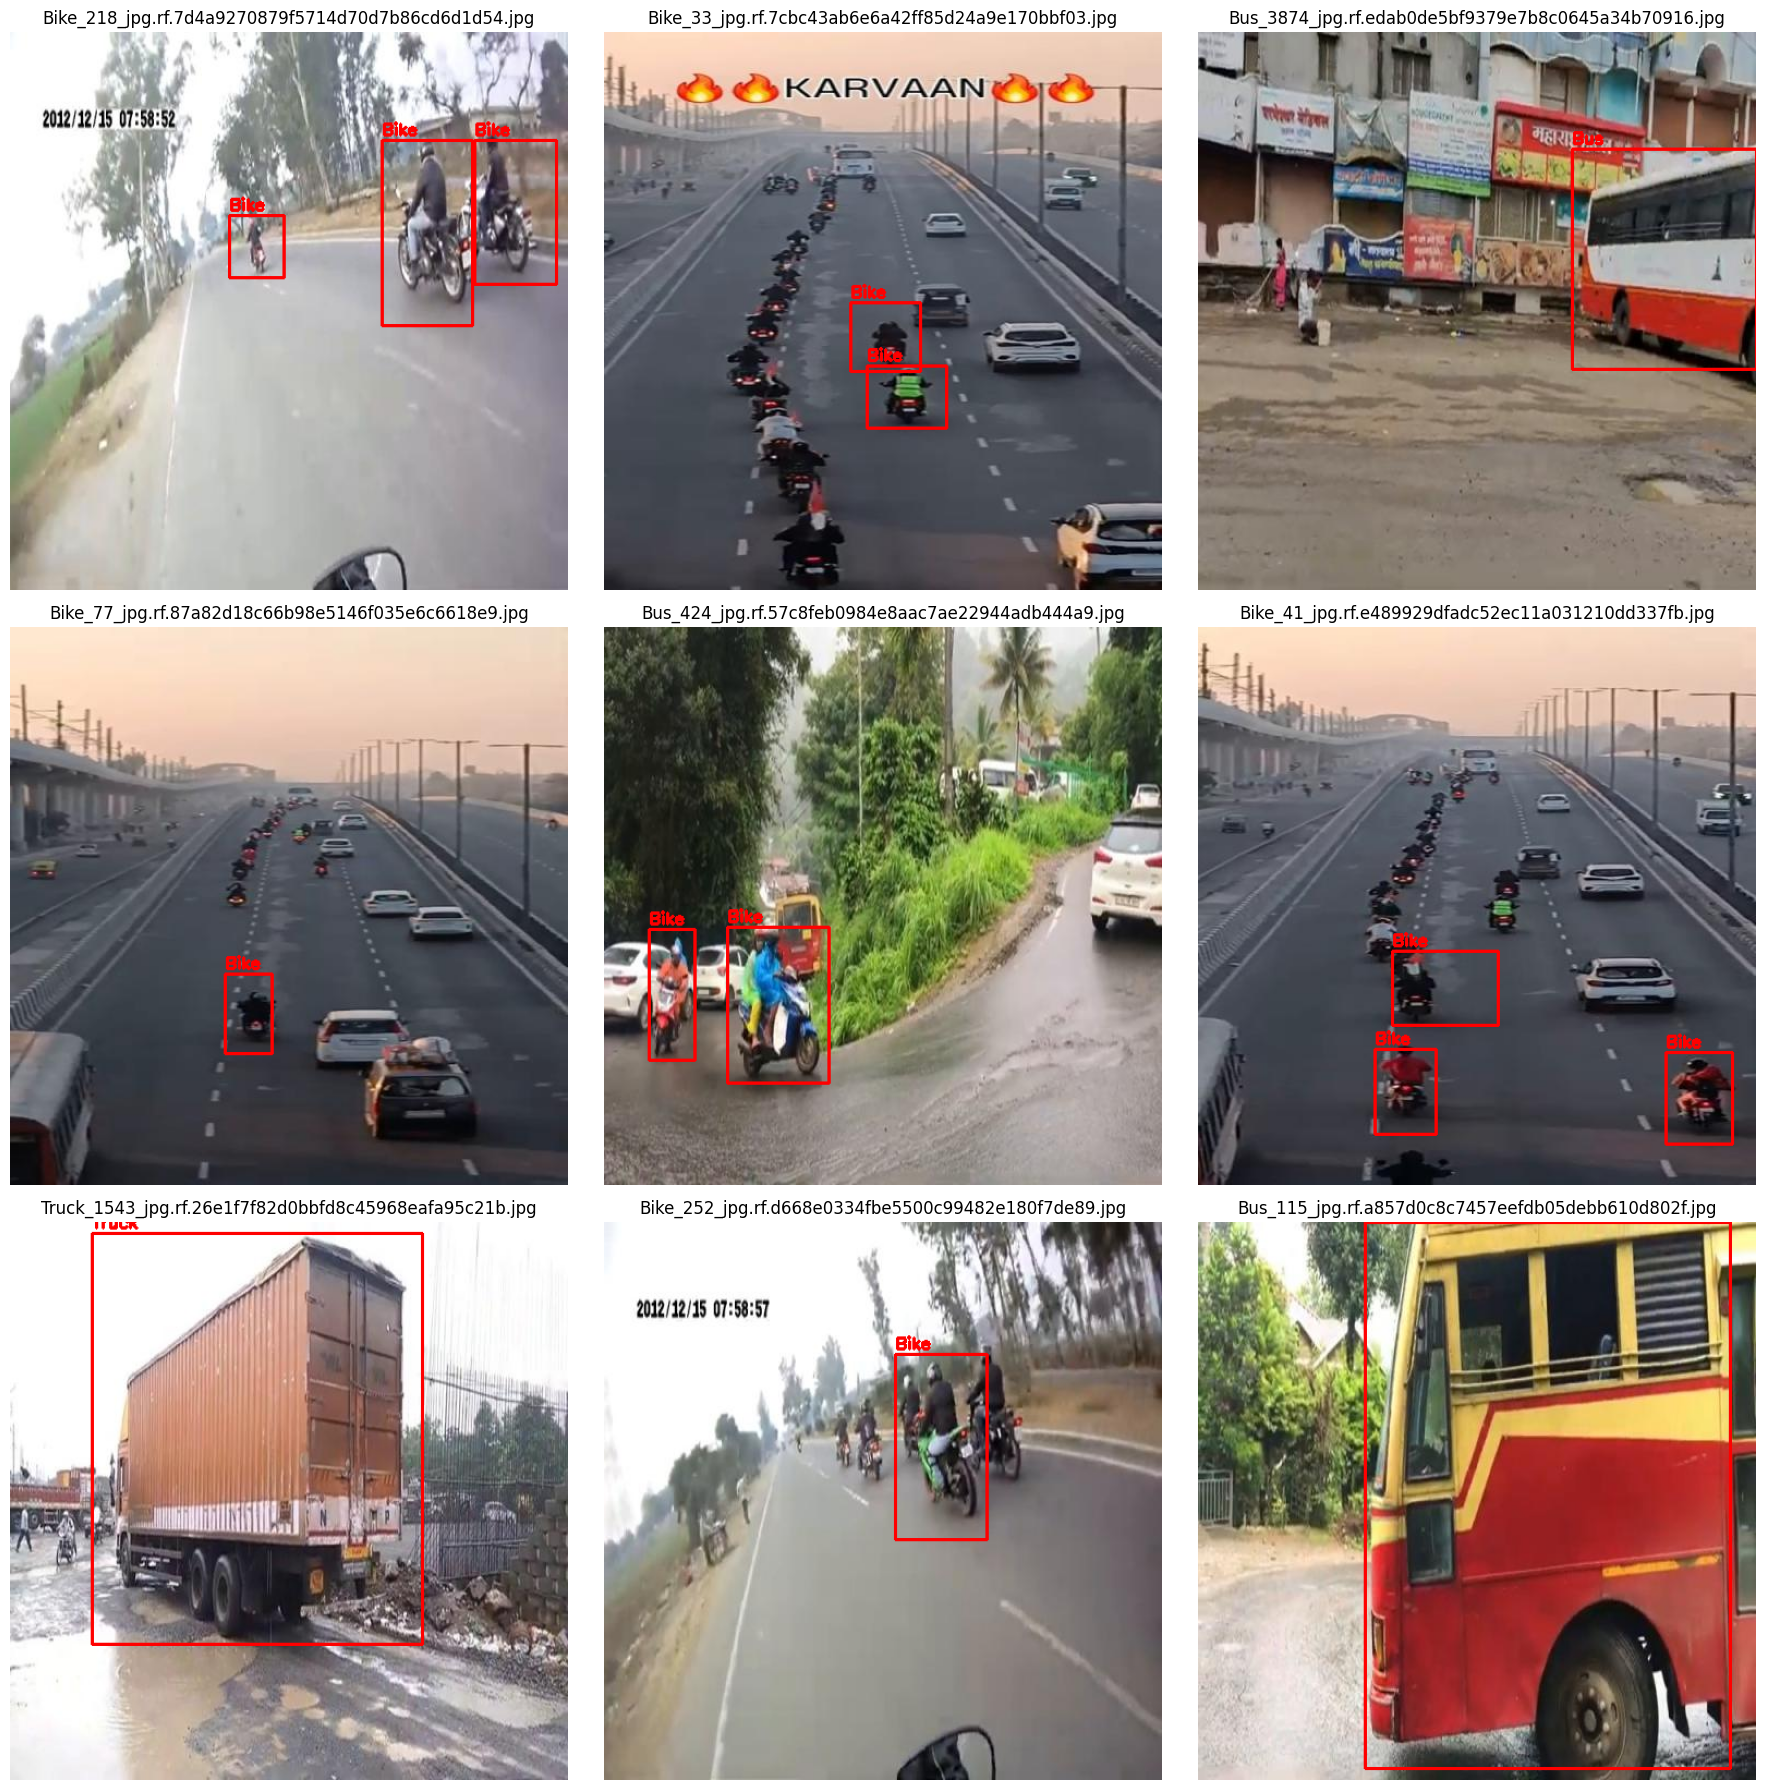

In [43]:
import random
import matplotlib.pyplot as plt

sample_images = random.sample(
    os.listdir(f"{CLEAN_DATASET}/images"),
    9
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18,18)
)

class_names = {
    0:"Autorickshaw",
    1:"Bike",
    2:"Bus",
    3:"Car",
    4:"Truck"
}

for ax, img_file in zip(axes.ravel(), sample_images):

    img_path = os.path.join(
        CLEAN_DATASET,
        "images",
        img_file
    )

    label_path = os.path.join(
        CLEAN_DATASET,
        "labels",
        img_file.rsplit(".",1)[0] + ".txt"
    )

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    with open(label_path,"r") as f:
        lines = f.readlines()

    for line in lines:

        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x-bw/2)*w)
        y1 = int((y-bh/2)*h)

        x2 = int((x+bw/2)*w)
        y2 = int((y+bh/2)*h)

        cv2.rectangle(
            image,
            (x1,y1),
            (x2,y2),
            (255,0,0),
            2
        )

        cv2.putText(
            image,
            class_names[int(cls)],
            (x1,y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            2
        )

    ax.imshow(image)
    ax.set_title(img_file)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [44]:
print("Dataset Status          : CLEAN")
print("Total Training Images   :", clean_images)
print("Total Training Labels   :", clean_labels)

print("Vehicle Classes")

for k,v in class_names.items():
    print(f"{k} : {v}")


Dataset Status          : CLEAN
Total Training Images   : 3848
Total Training Labels   : 3848
Vehicle Classes
0 : Autorickshaw
1 : Bike
2 : Bus
3 : Car
4 : Truck


In [45]:
import pandas as pd

distribution_df = pd.DataFrame({
    "Class":["Autorickshaw","Bike","Bus","Car","Truck"],
    "Count":[825,1113,761,1774,881]
})

distribution_df["Percentage"] = (
    distribution_df["Count"] /
    distribution_df["Count"].sum()
)*100

distribution_df

,Class,Count,Percentage
0,Autorickshaw,825,15.409040
1,Bike,1113,20.788196
2,Bus,761,14.213672
3,Car,1774,33.134105
4,Truck,881,16.454987


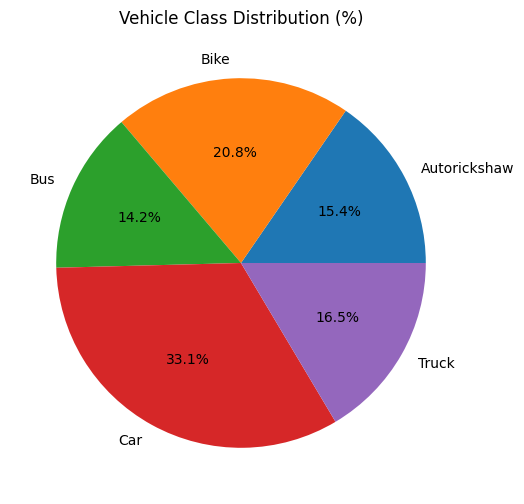

In [46]:
plt.figure(figsize=(6,6))

plt.pie(
    distribution_df["Count"],
    labels=distribution_df["Class"],
    autopct="%1.1f%%"
)

plt.title("Vehicle Class Distribution (%)")

plt.show()

In [47]:
import os

for root, dirs, files in os.walk("/kaggle/working/clean_dataset"):
    print(root)
    print("Files:", len(files))
    print("-"*50)

/kaggle/working/clean_dataset
Files: 0
--------------------------------------------------
/kaggle/working/clean_dataset/labels
Files: 3848
--------------------------------------------------
/kaggle/working/clean_dataset/images
Files: 3848
--------------------------------------------------


In [48]:
import os

BASE_DIR = "/kaggle/working/vehicle_dataset"

folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Folder")

Folder


In [49]:
import os
import shutil
import random

SOURCE_IMAGES = "/kaggle/working/clean_dataset/images"
SOURCE_LABELS = "/kaggle/working/clean_dataset/labels"

all_images = os.listdir(SOURCE_IMAGES)

random.seed(42)
random.shuffle(all_images)

split_idx = int(len(all_images) * 0.8)

train_images = all_images[:split_idx]
valid_images = all_images[split_idx:]

print("Train Images :", len(train_images))
print("Validation Images :", len(valid_images))

Train Images : 3078
Validation Images : 770


In [50]:
for img_file in train_images:

    label_file = img_file.rsplit(".",1)[0] + ".txt"

    shutil.copy(
        os.path.join(SOURCE_IMAGES,img_file),
        os.path.join(BASE_DIR,"train/images",img_file)
    )

    shutil.copy(
        os.path.join(SOURCE_LABELS,label_file),
        os.path.join(BASE_DIR,"train/labels",label_file)
    )


In [51]:
for img_file in valid_images:

    label_file = img_file.rsplit(".",1)[0] + ".txt"

    shutil.copy(
        os.path.join(SOURCE_IMAGES,img_file),
        os.path.join(BASE_DIR,"valid/images",img_file)
    )

    shutil.copy(
        os.path.join(SOURCE_LABELS,label_file),
        os.path.join(BASE_DIR,"valid/labels",label_file)
    )


In [52]:
print("Train Images :",
      len(os.listdir(f"{BASE_DIR}/train/images")))

print("Train Labels :",
      len(os.listdir(f"{BASE_DIR}/train/labels")))

print("Valid Images :",
      len(os.listdir(f"{BASE_DIR}/valid/images")))

print("Valid Labels :",
      len(os.listdir(f"{BASE_DIR}/valid/labels")))

Train Images : 3078
Train Labels : 3078
Valid Images : 770
Valid Labels : 770


In [53]:
yaml_content = """
path: /kaggle/working/vehicle_dataset

train: train/images
val: valid/images

names:
  0: autorickshaw
  1: bike
  2: bus
  3: car
  4: truck
"""

with open("/kaggle/working/vehicle_dataset/data.yaml","w") as f:
    f.write(yaml_content)


In [54]:
with open("/kaggle/working/vehicle_dataset/data.yaml") as f:
    print(f.read())


path: /kaggle/working/vehicle_dataset

train: train/images
val: valid/images

names:
  0: autorickshaw
  1: bike
  2: bus
  3: car
  4: truck



In [55]:
!pip install -q ultralytics

In [56]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")


In [57]:
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [58]:
results = model.train(
    data="/kaggle/working/vehicle_dataset/data.yaml",

    epochs=50,
    imgsz=640,

    batch=16,

    optimizer="AdamW",
    lr0=0.001,

    patience=15,

    workers=2,
    cache=True,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,

    project="Indian_Vehicle_Detection",
    name="YOLOv8n_Custom",

    pretrained=True,
    verbose=True
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/vehicle_dataset/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

In [59]:
import os

results_dir = "/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom"

for file in sorted(os.listdir(results_dir)):
    print(file)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch7720.jpg
train_batch7721.jpg
train_batch7722.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


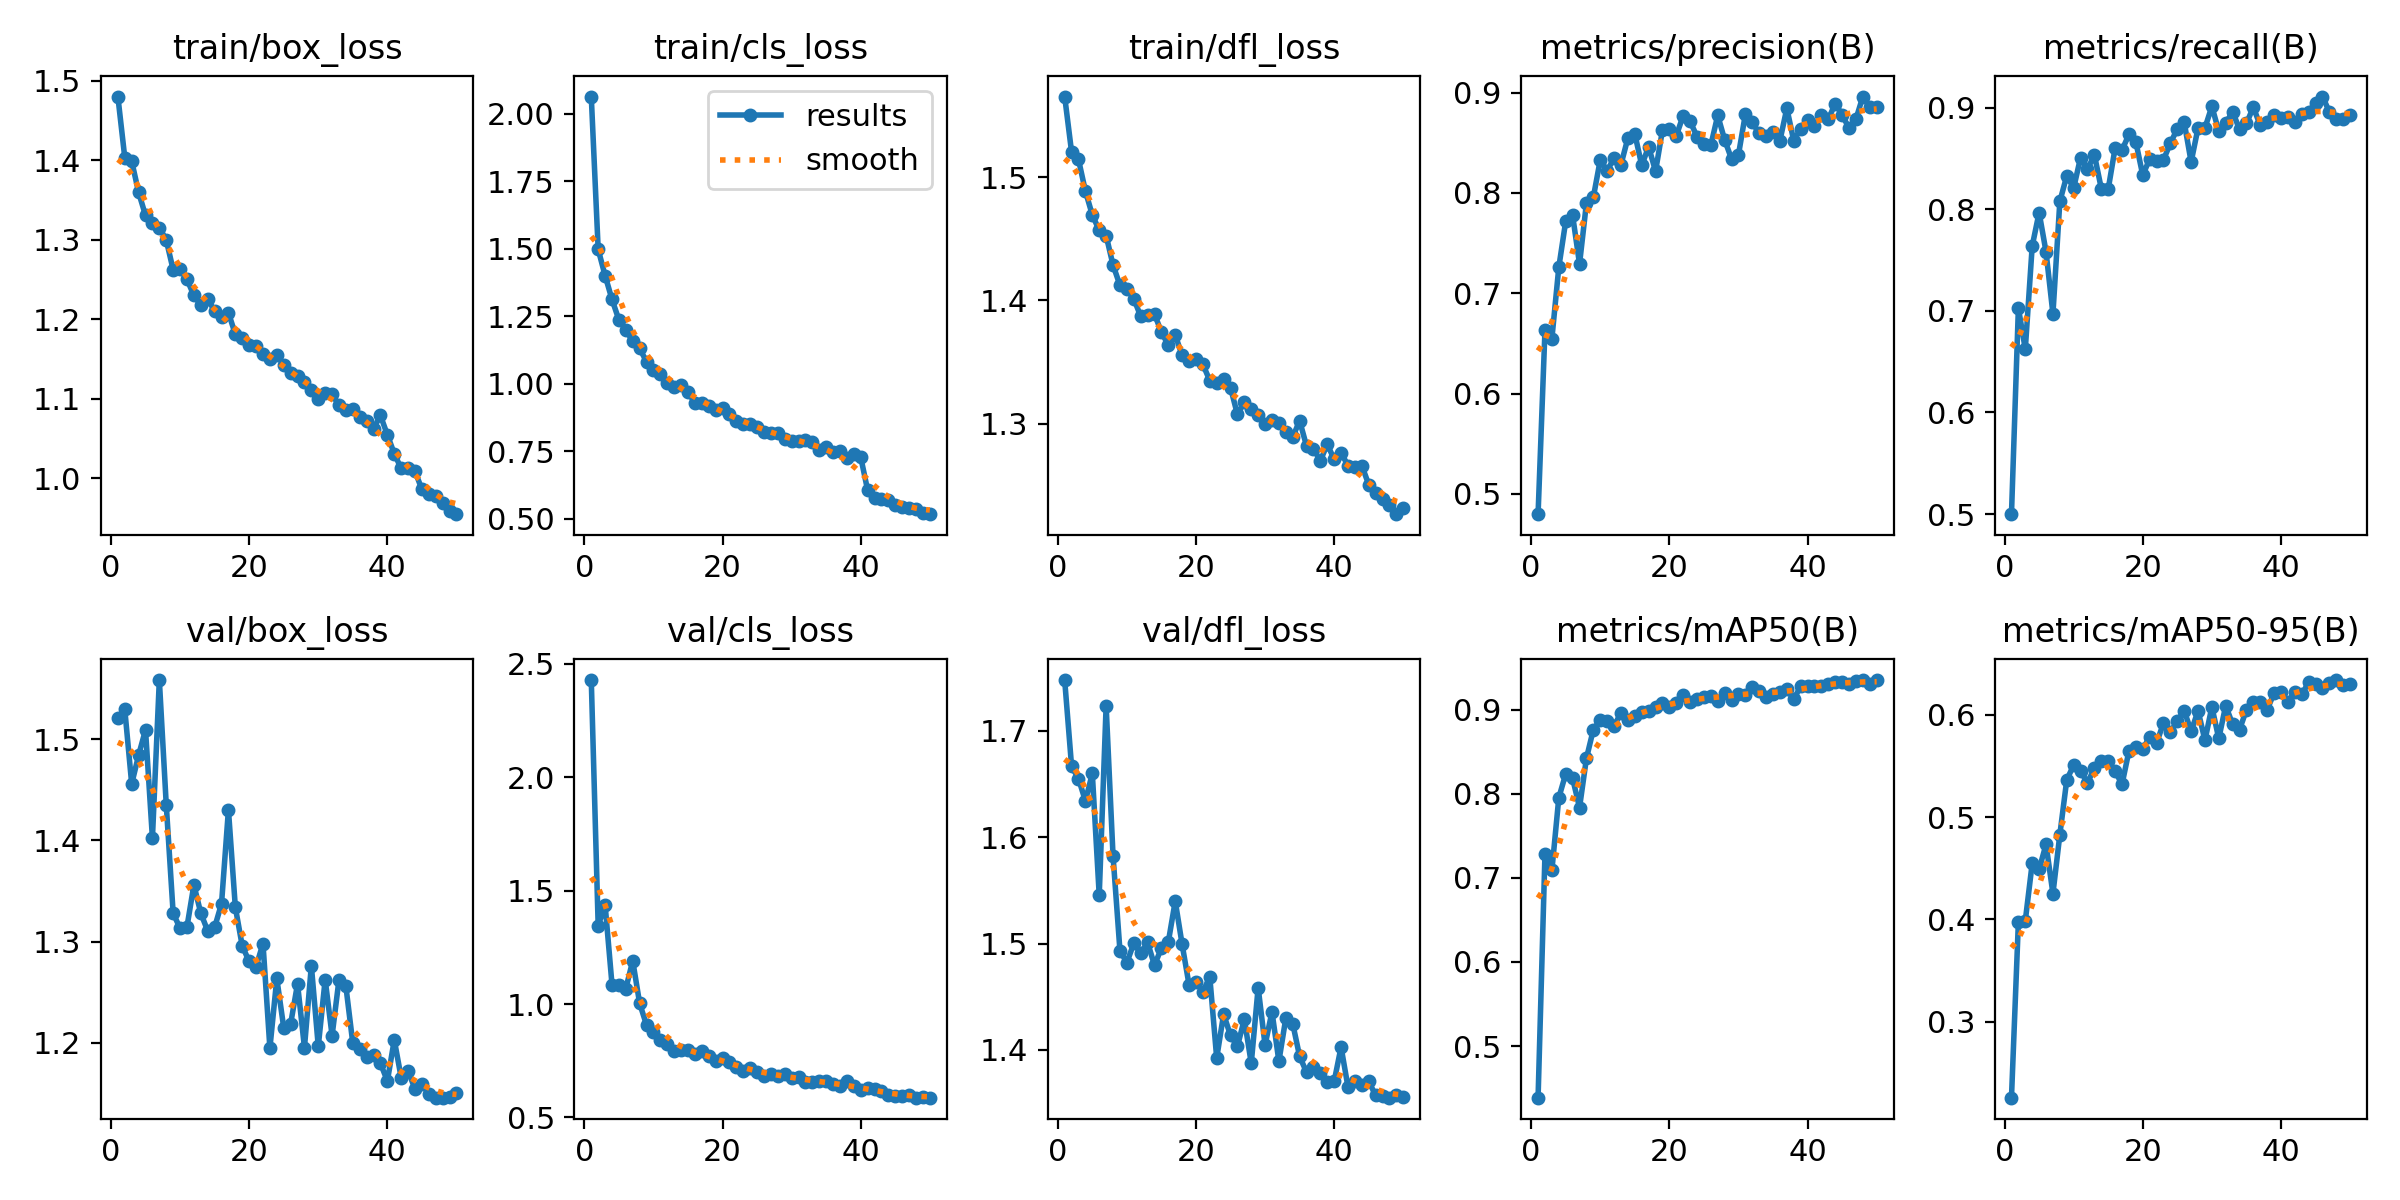

In [60]:
from IPython.display import Image

Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/results.png"
)

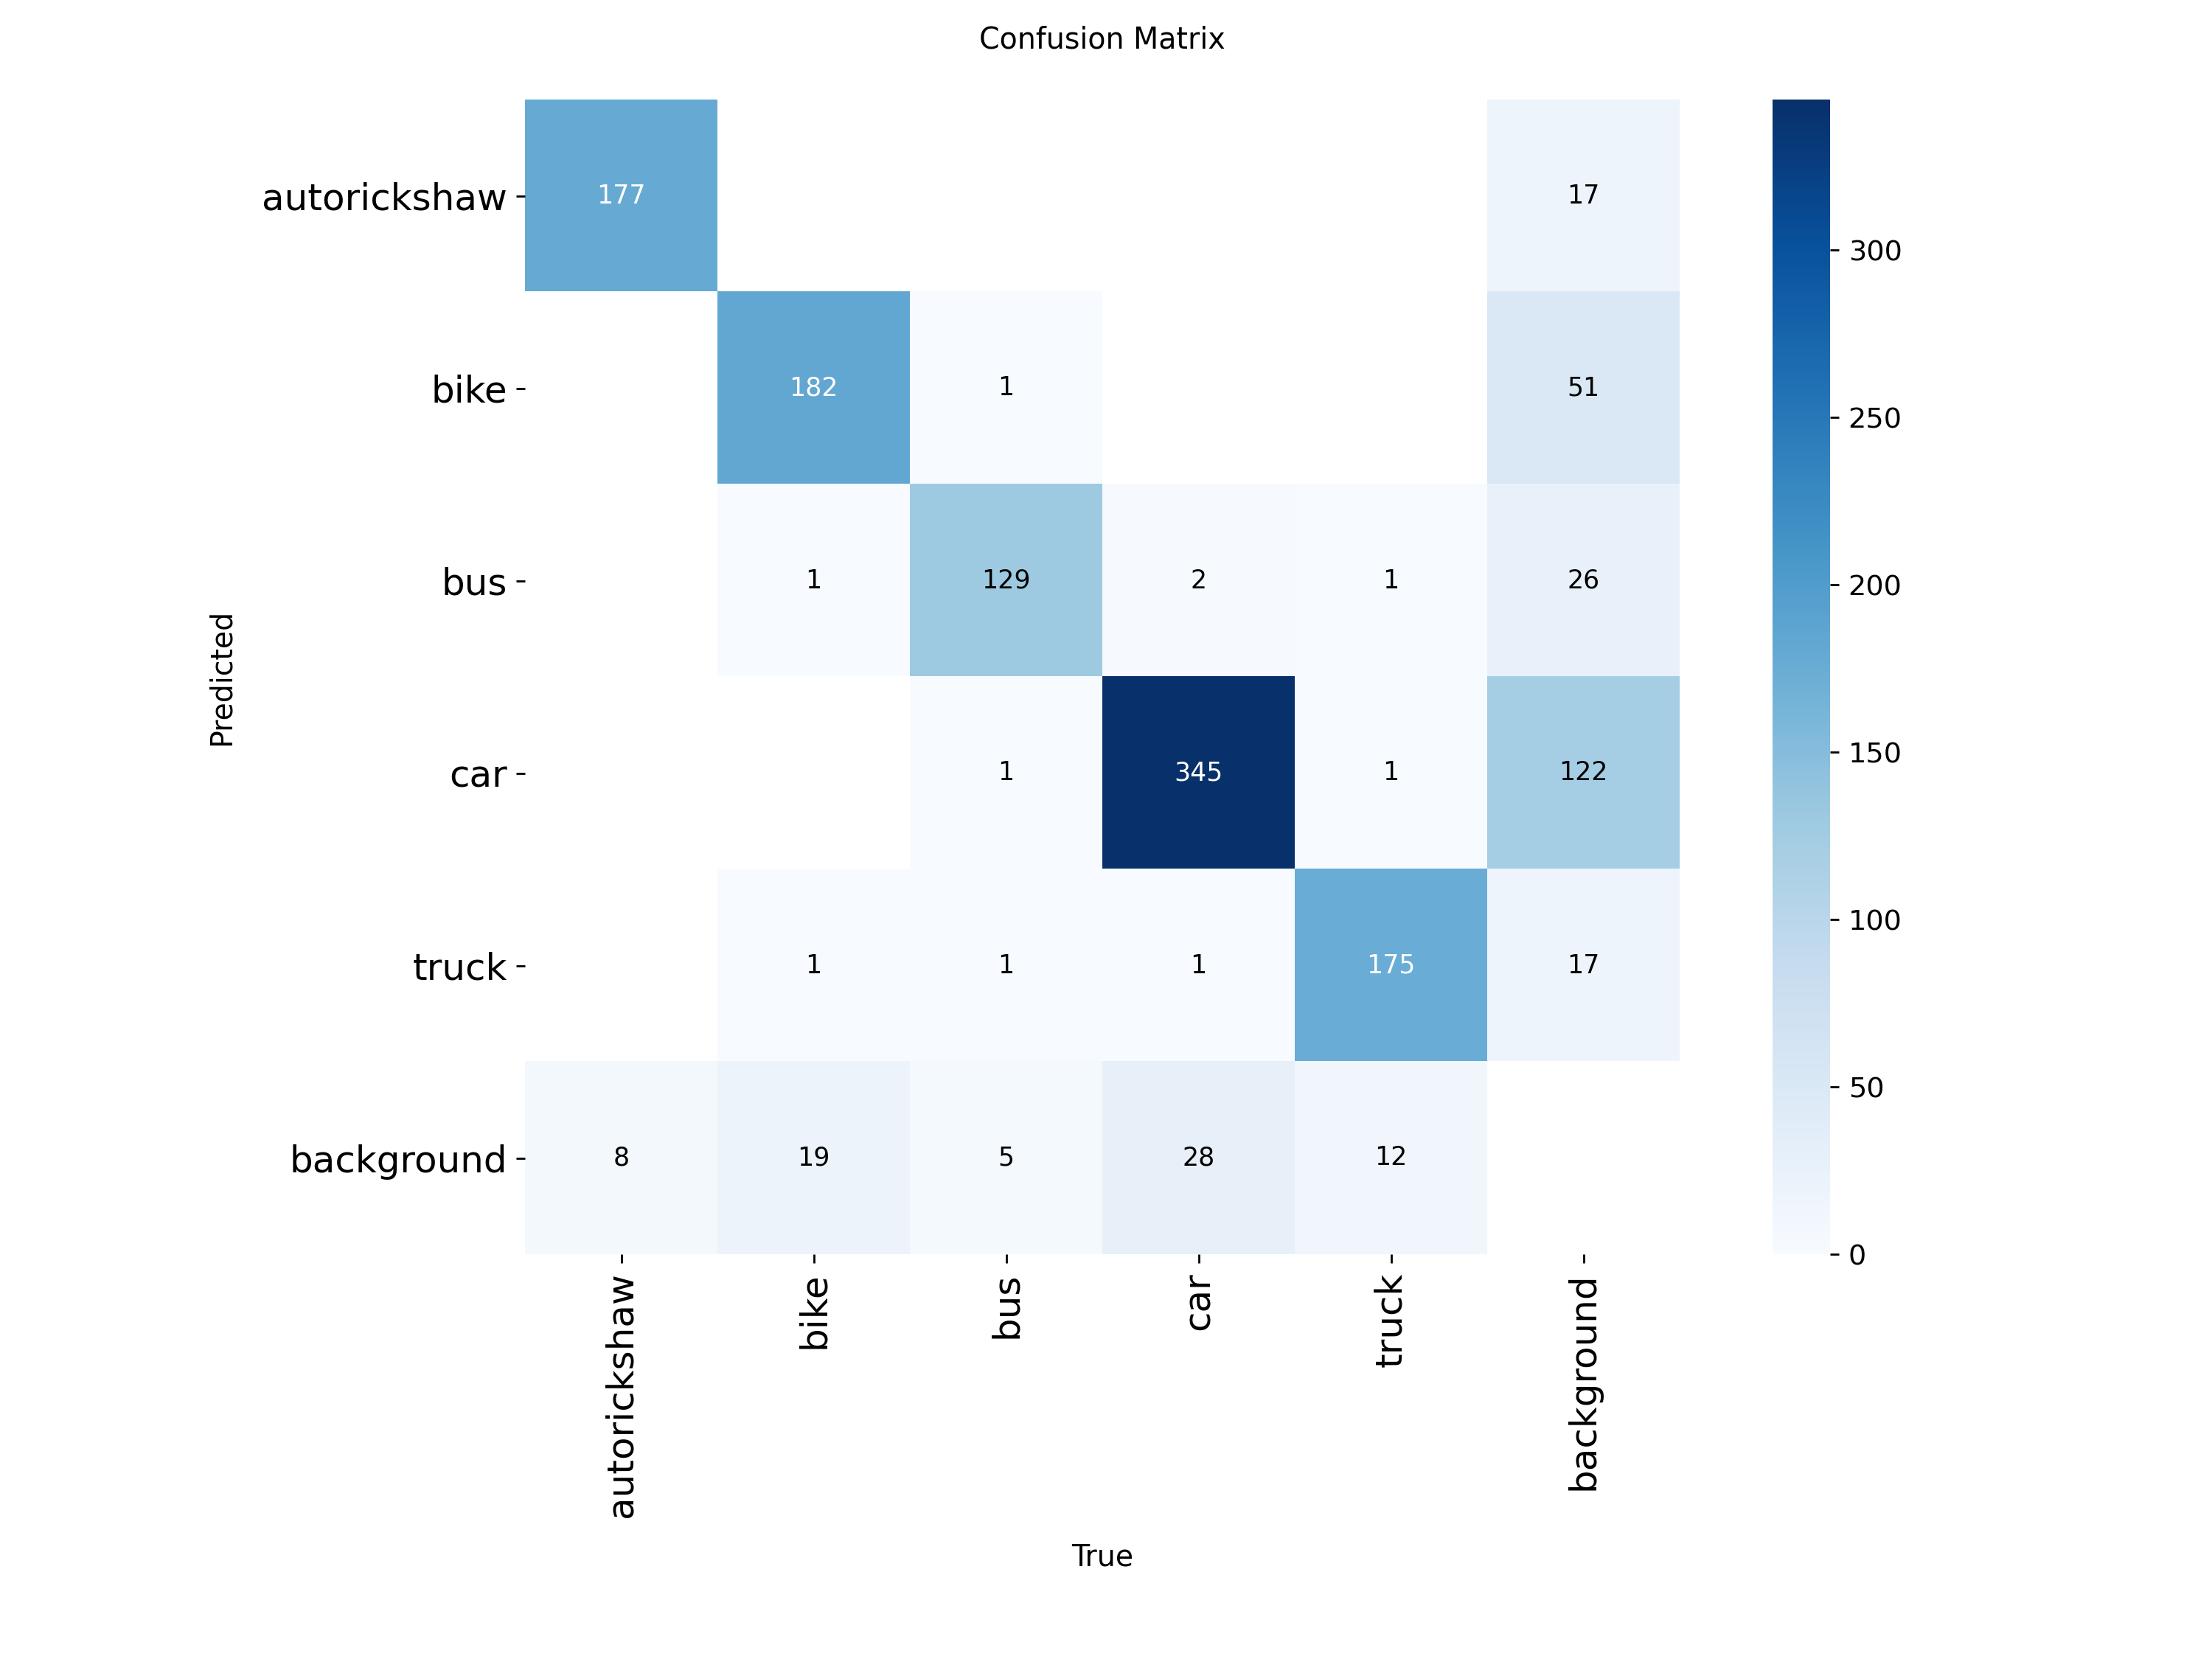

In [61]:
Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/confusion_matrix.png"
)

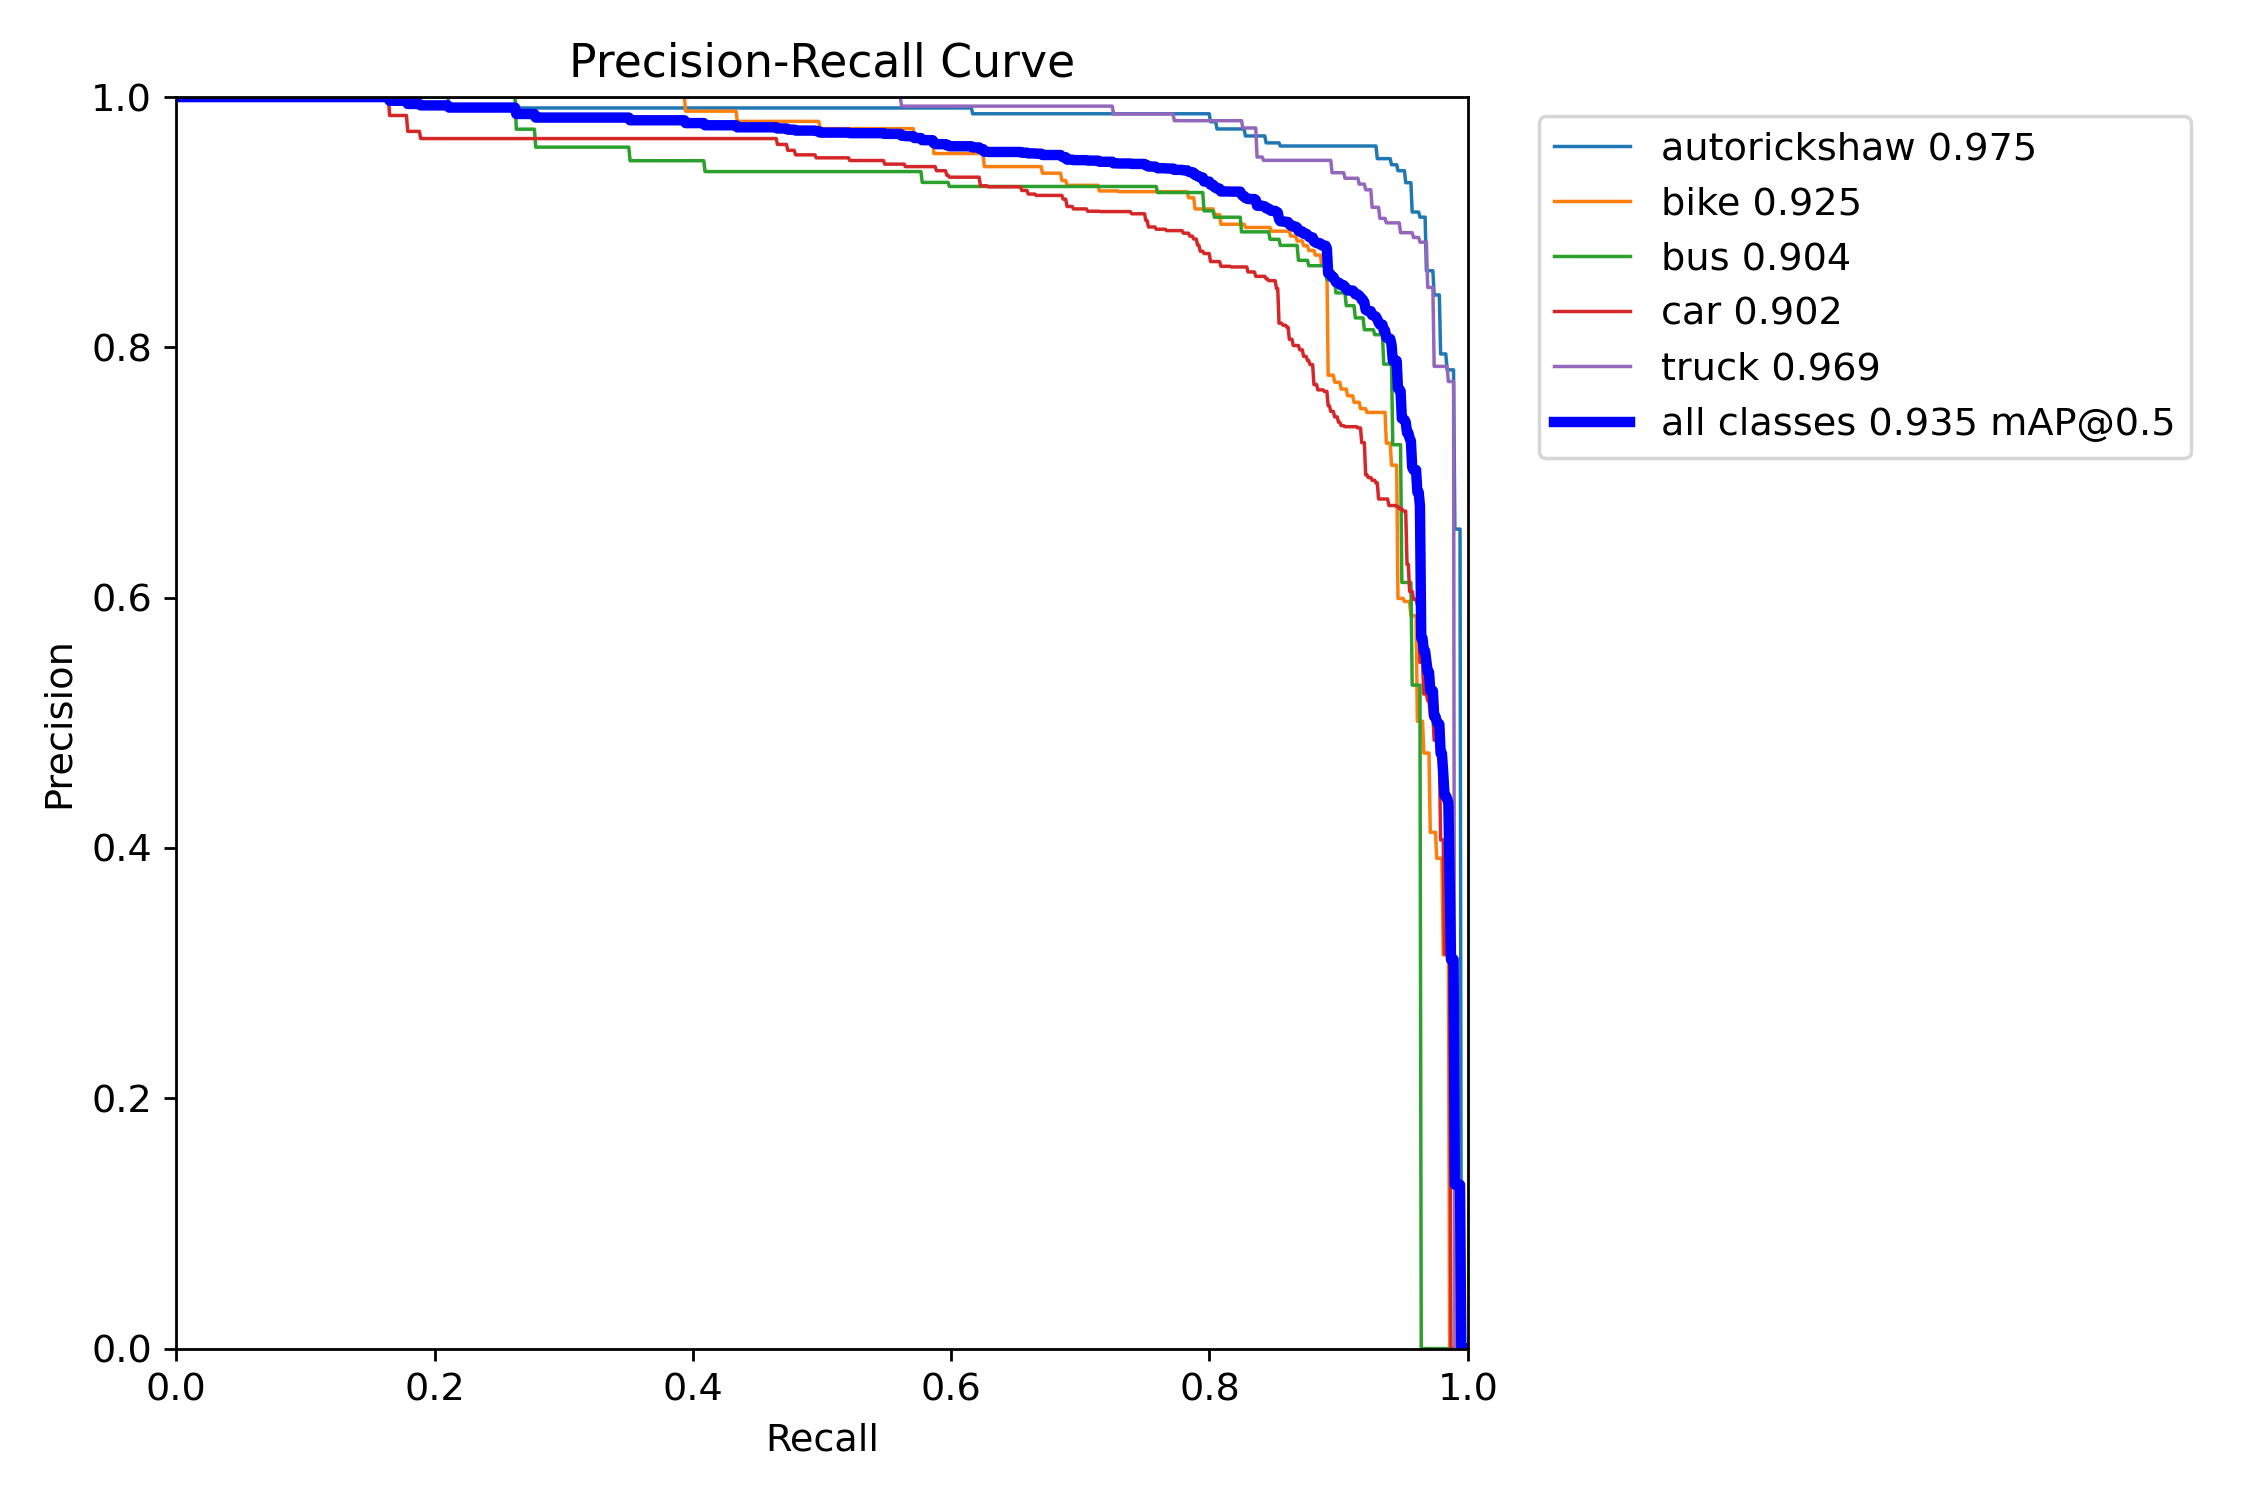

In [64]:
from IPython.display import Image

Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/BoxPR_curve.png"
)

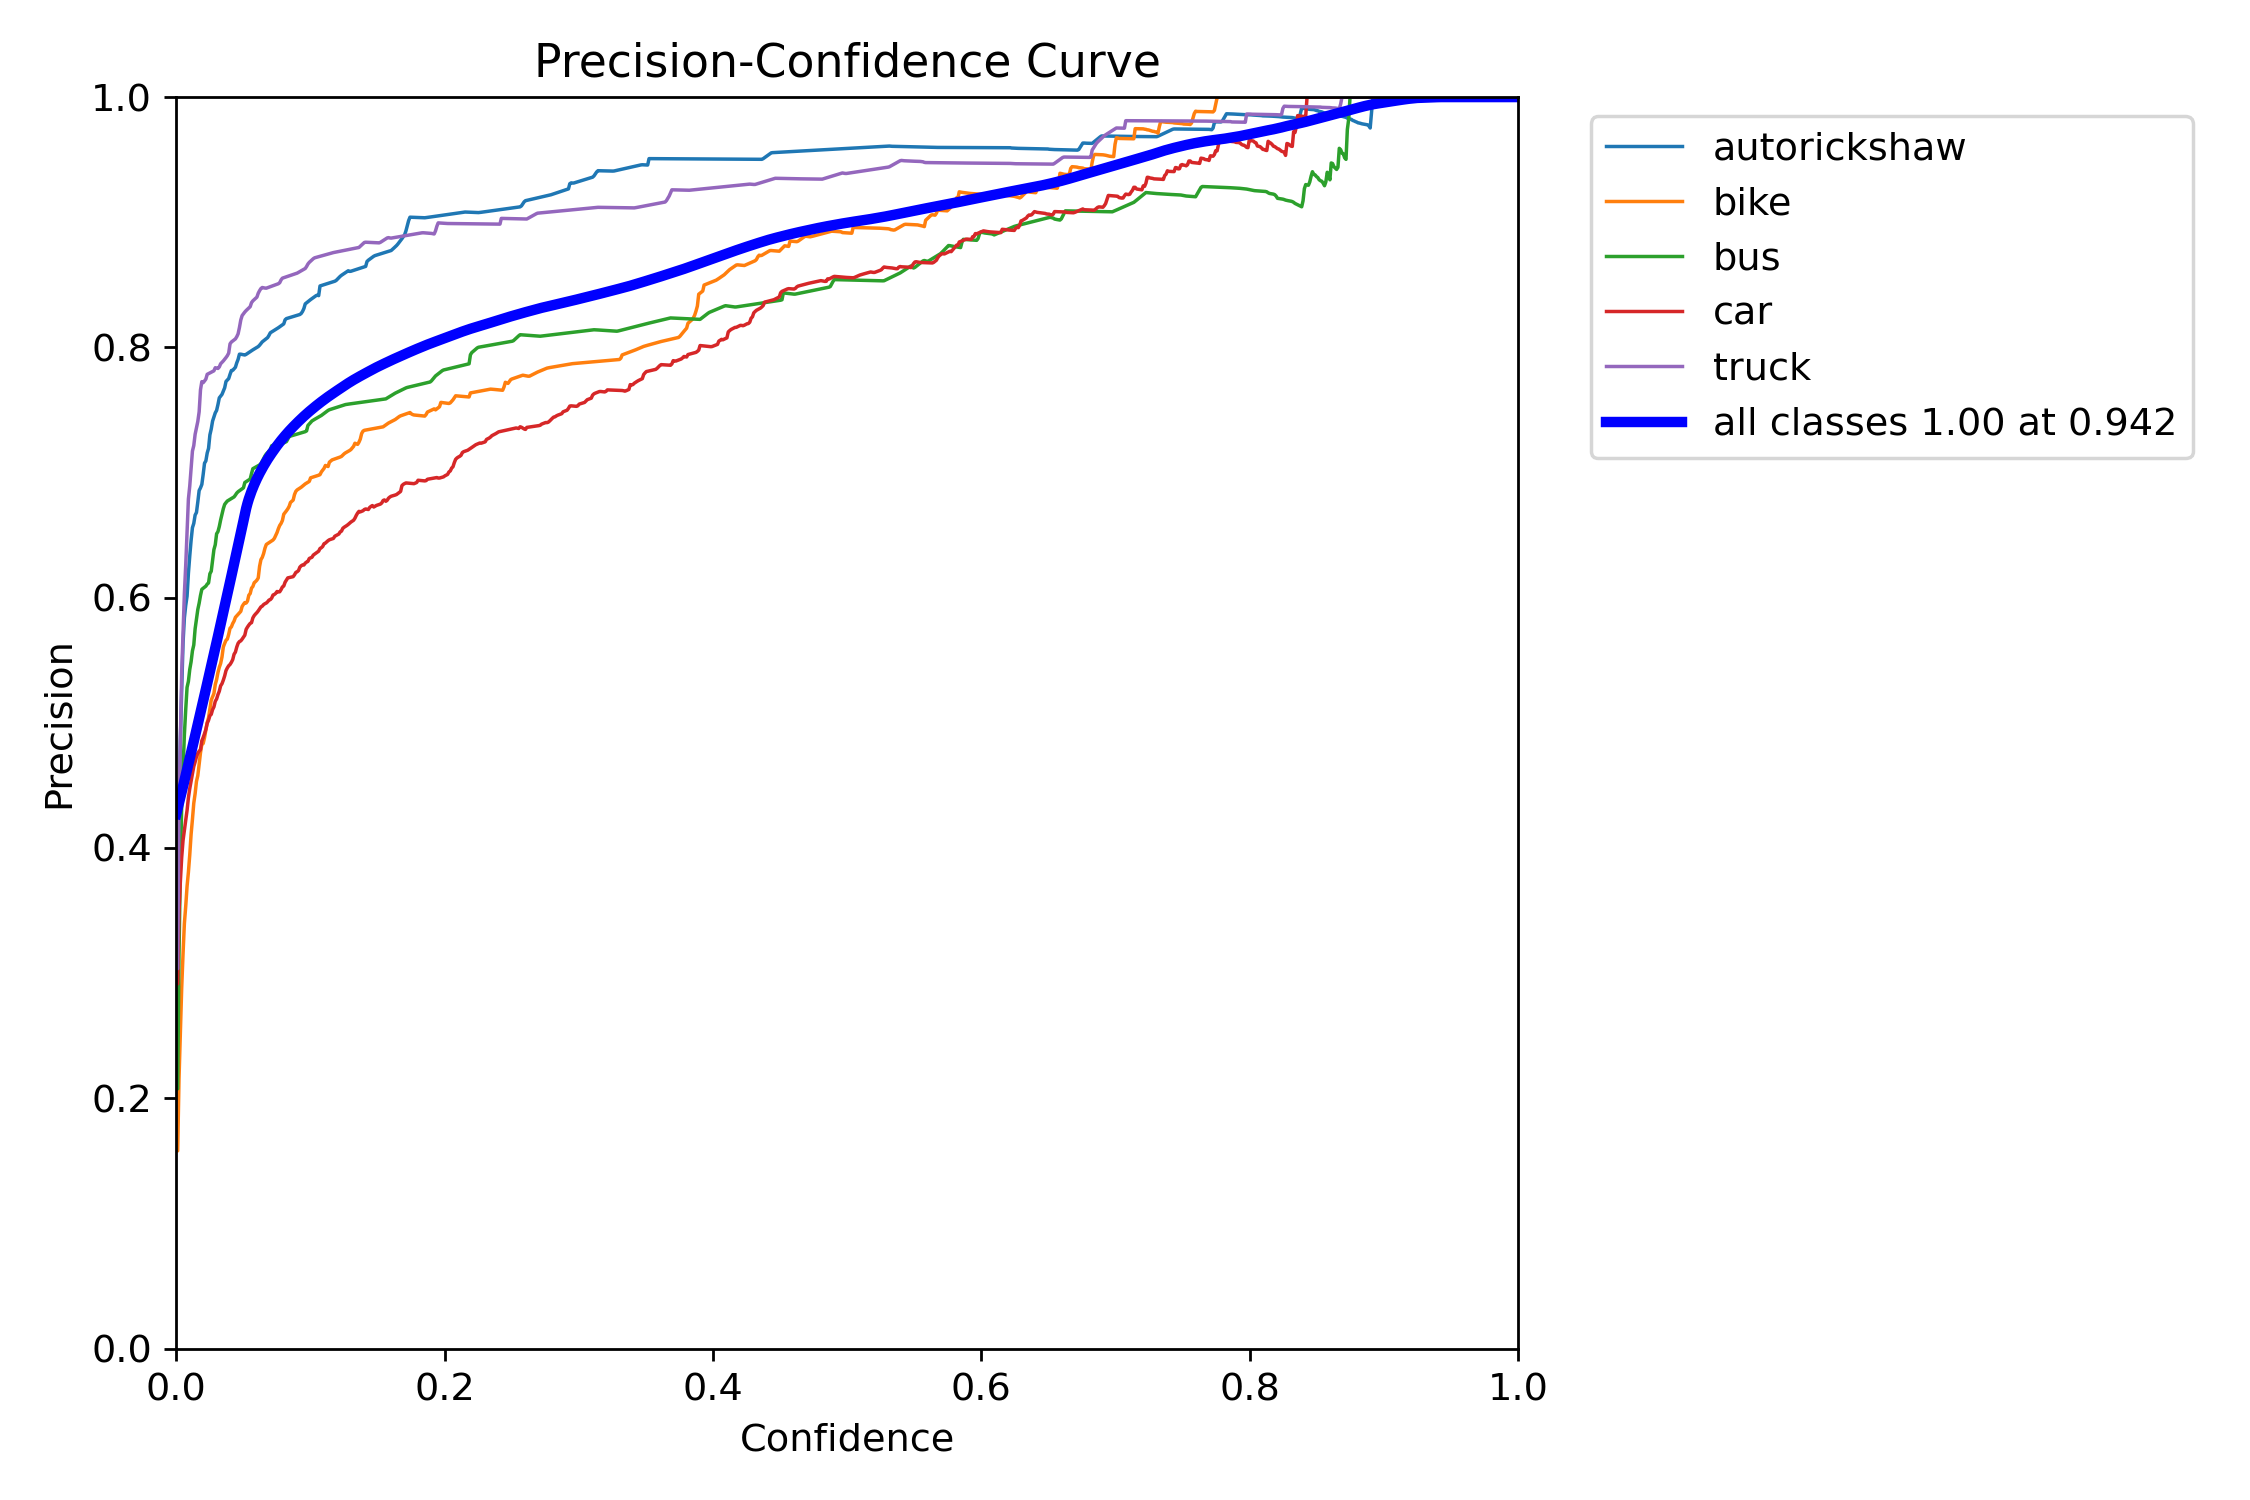

In [65]:
Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/BoxP_curve.png"
)

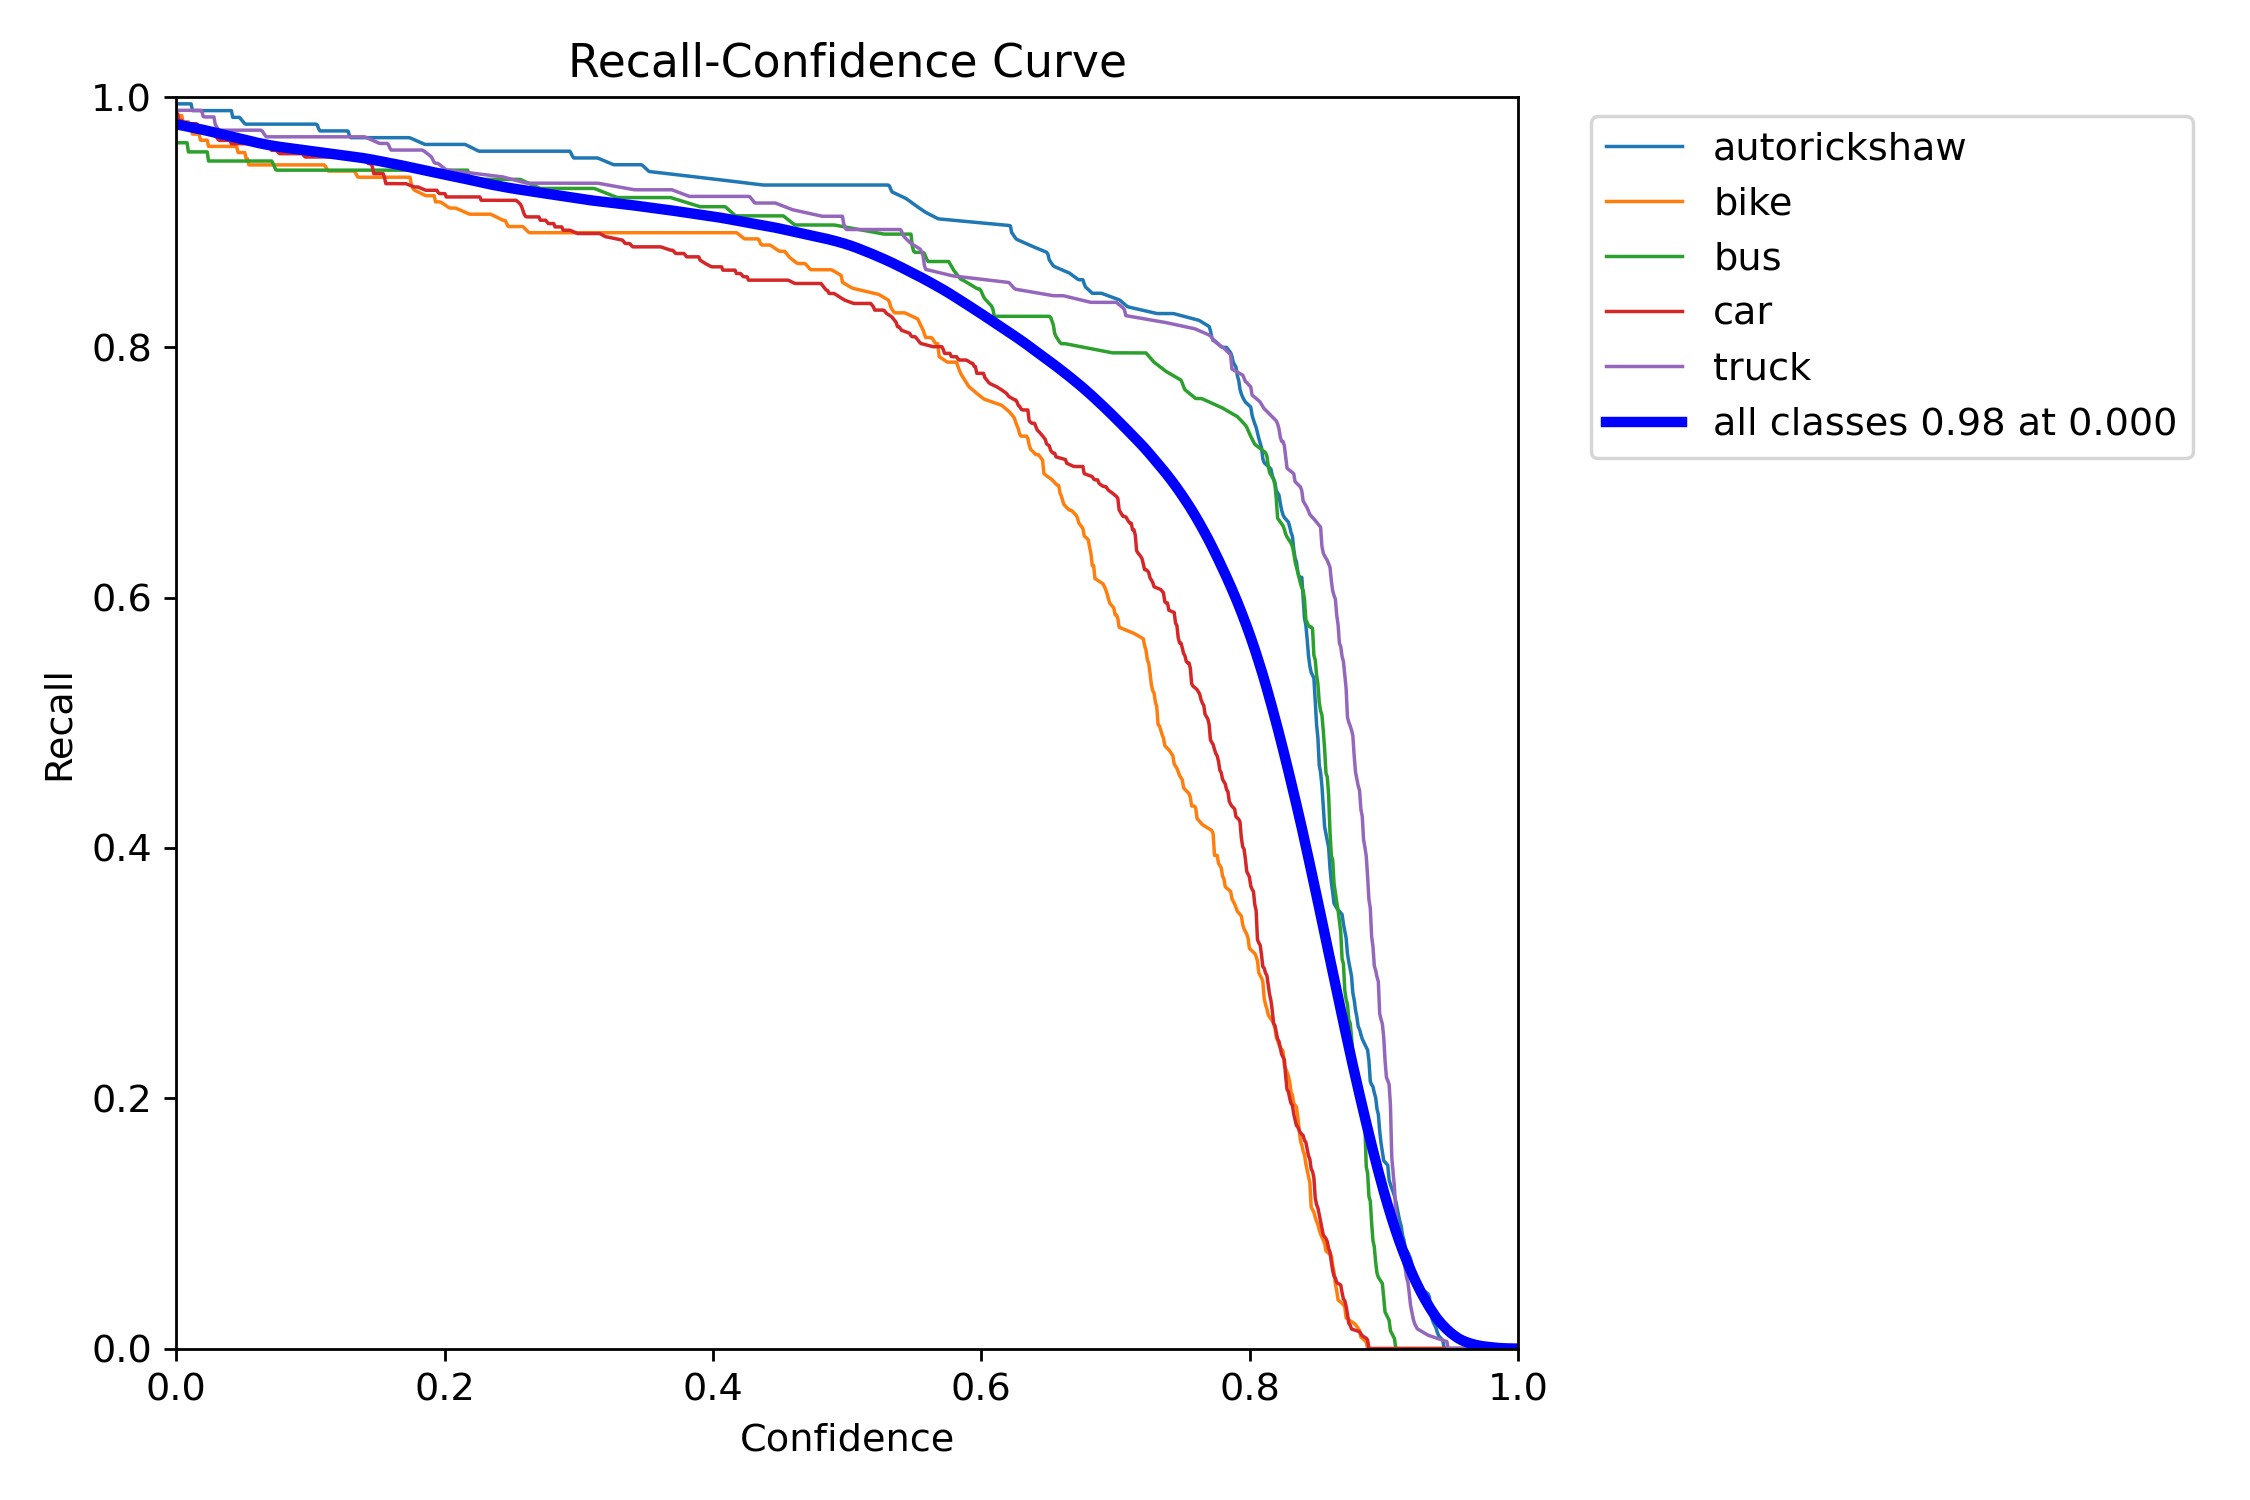

In [66]:
Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/BoxR_curve.png"
)

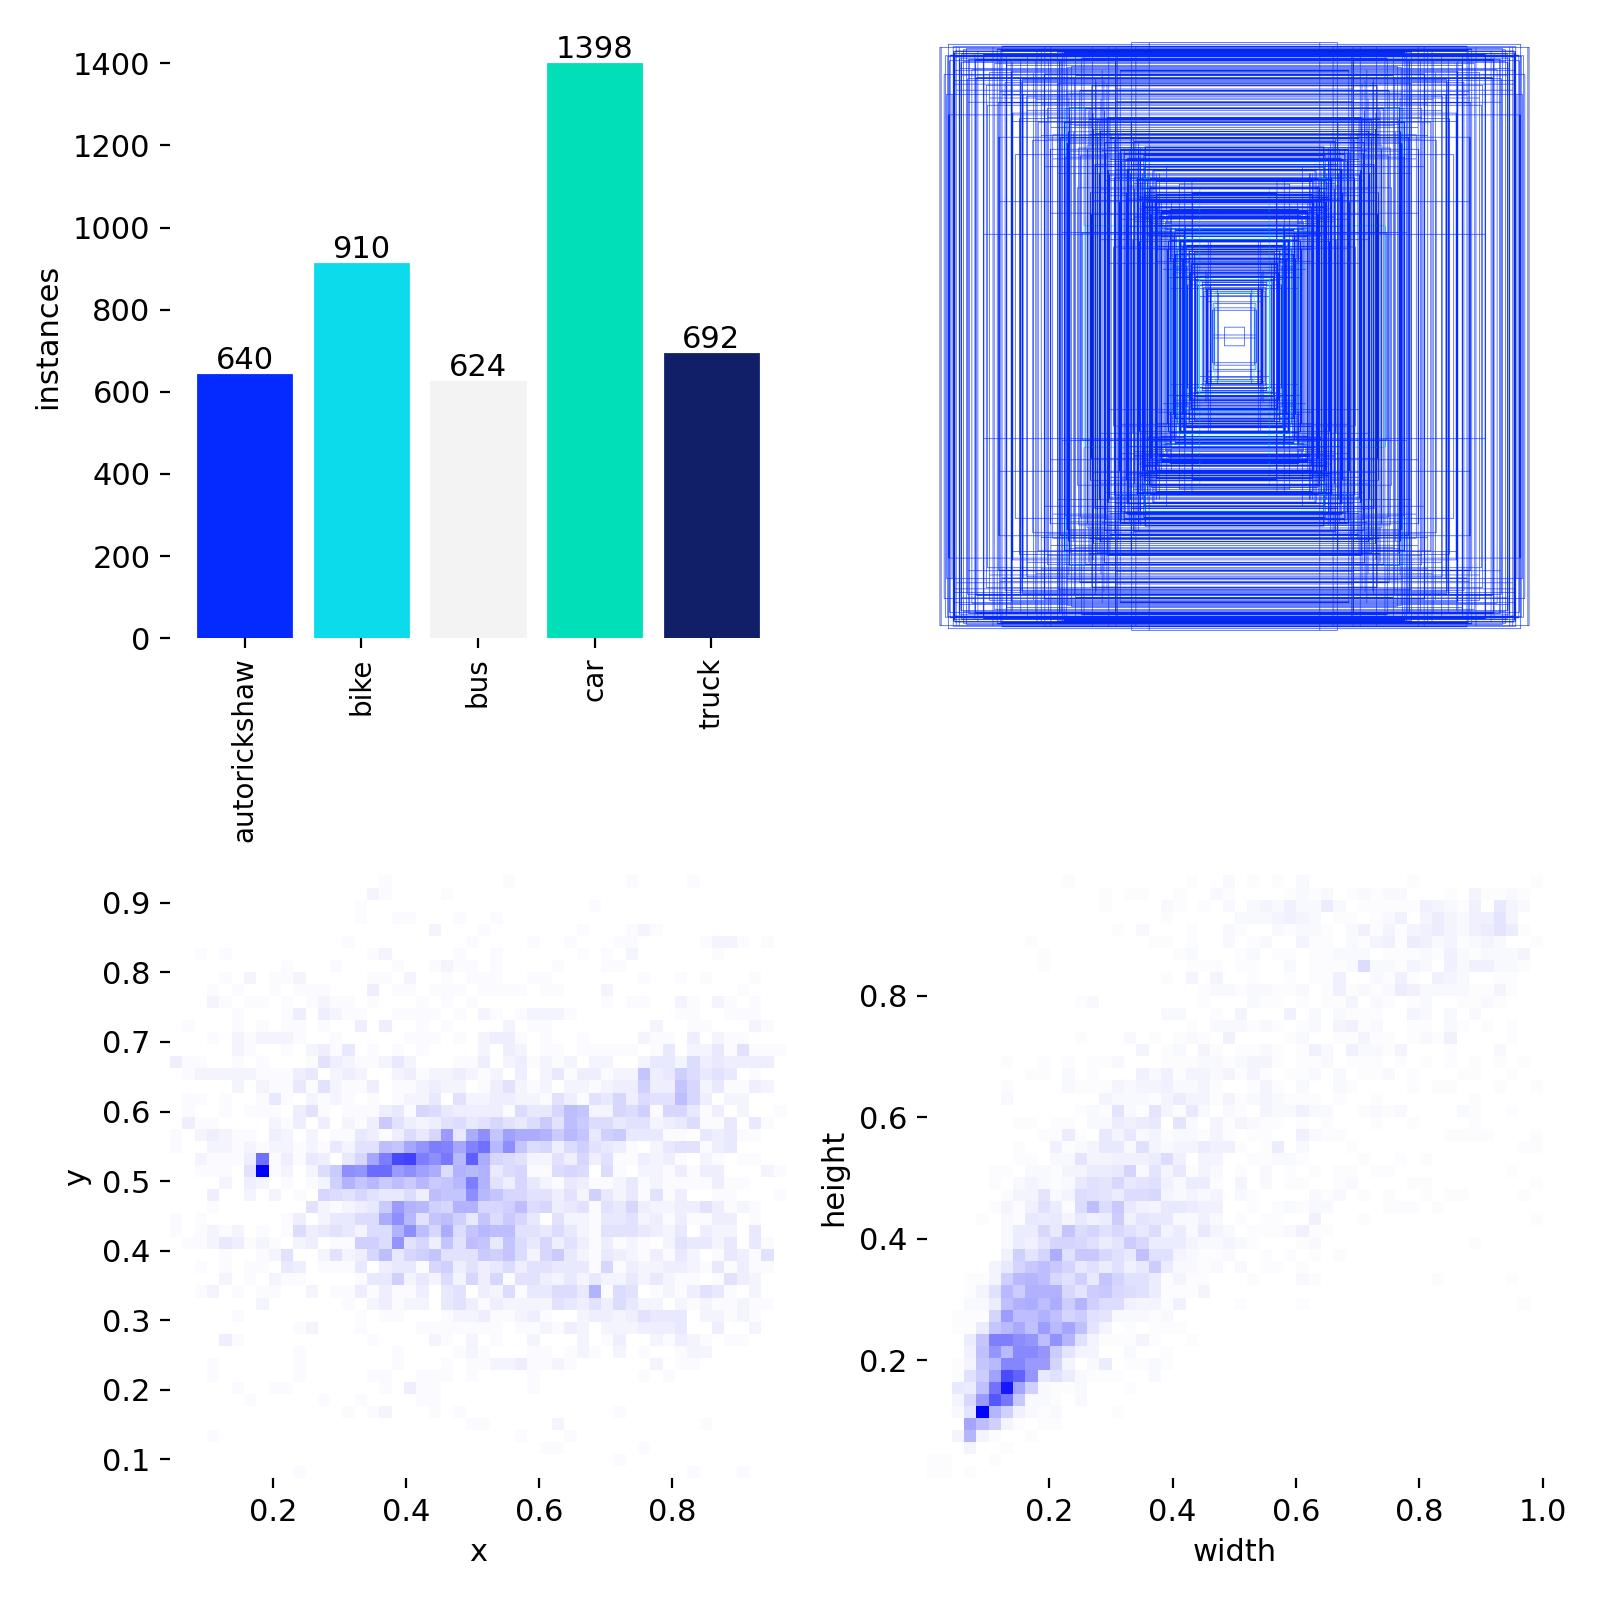

In [67]:
Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/labels.jpg"
)

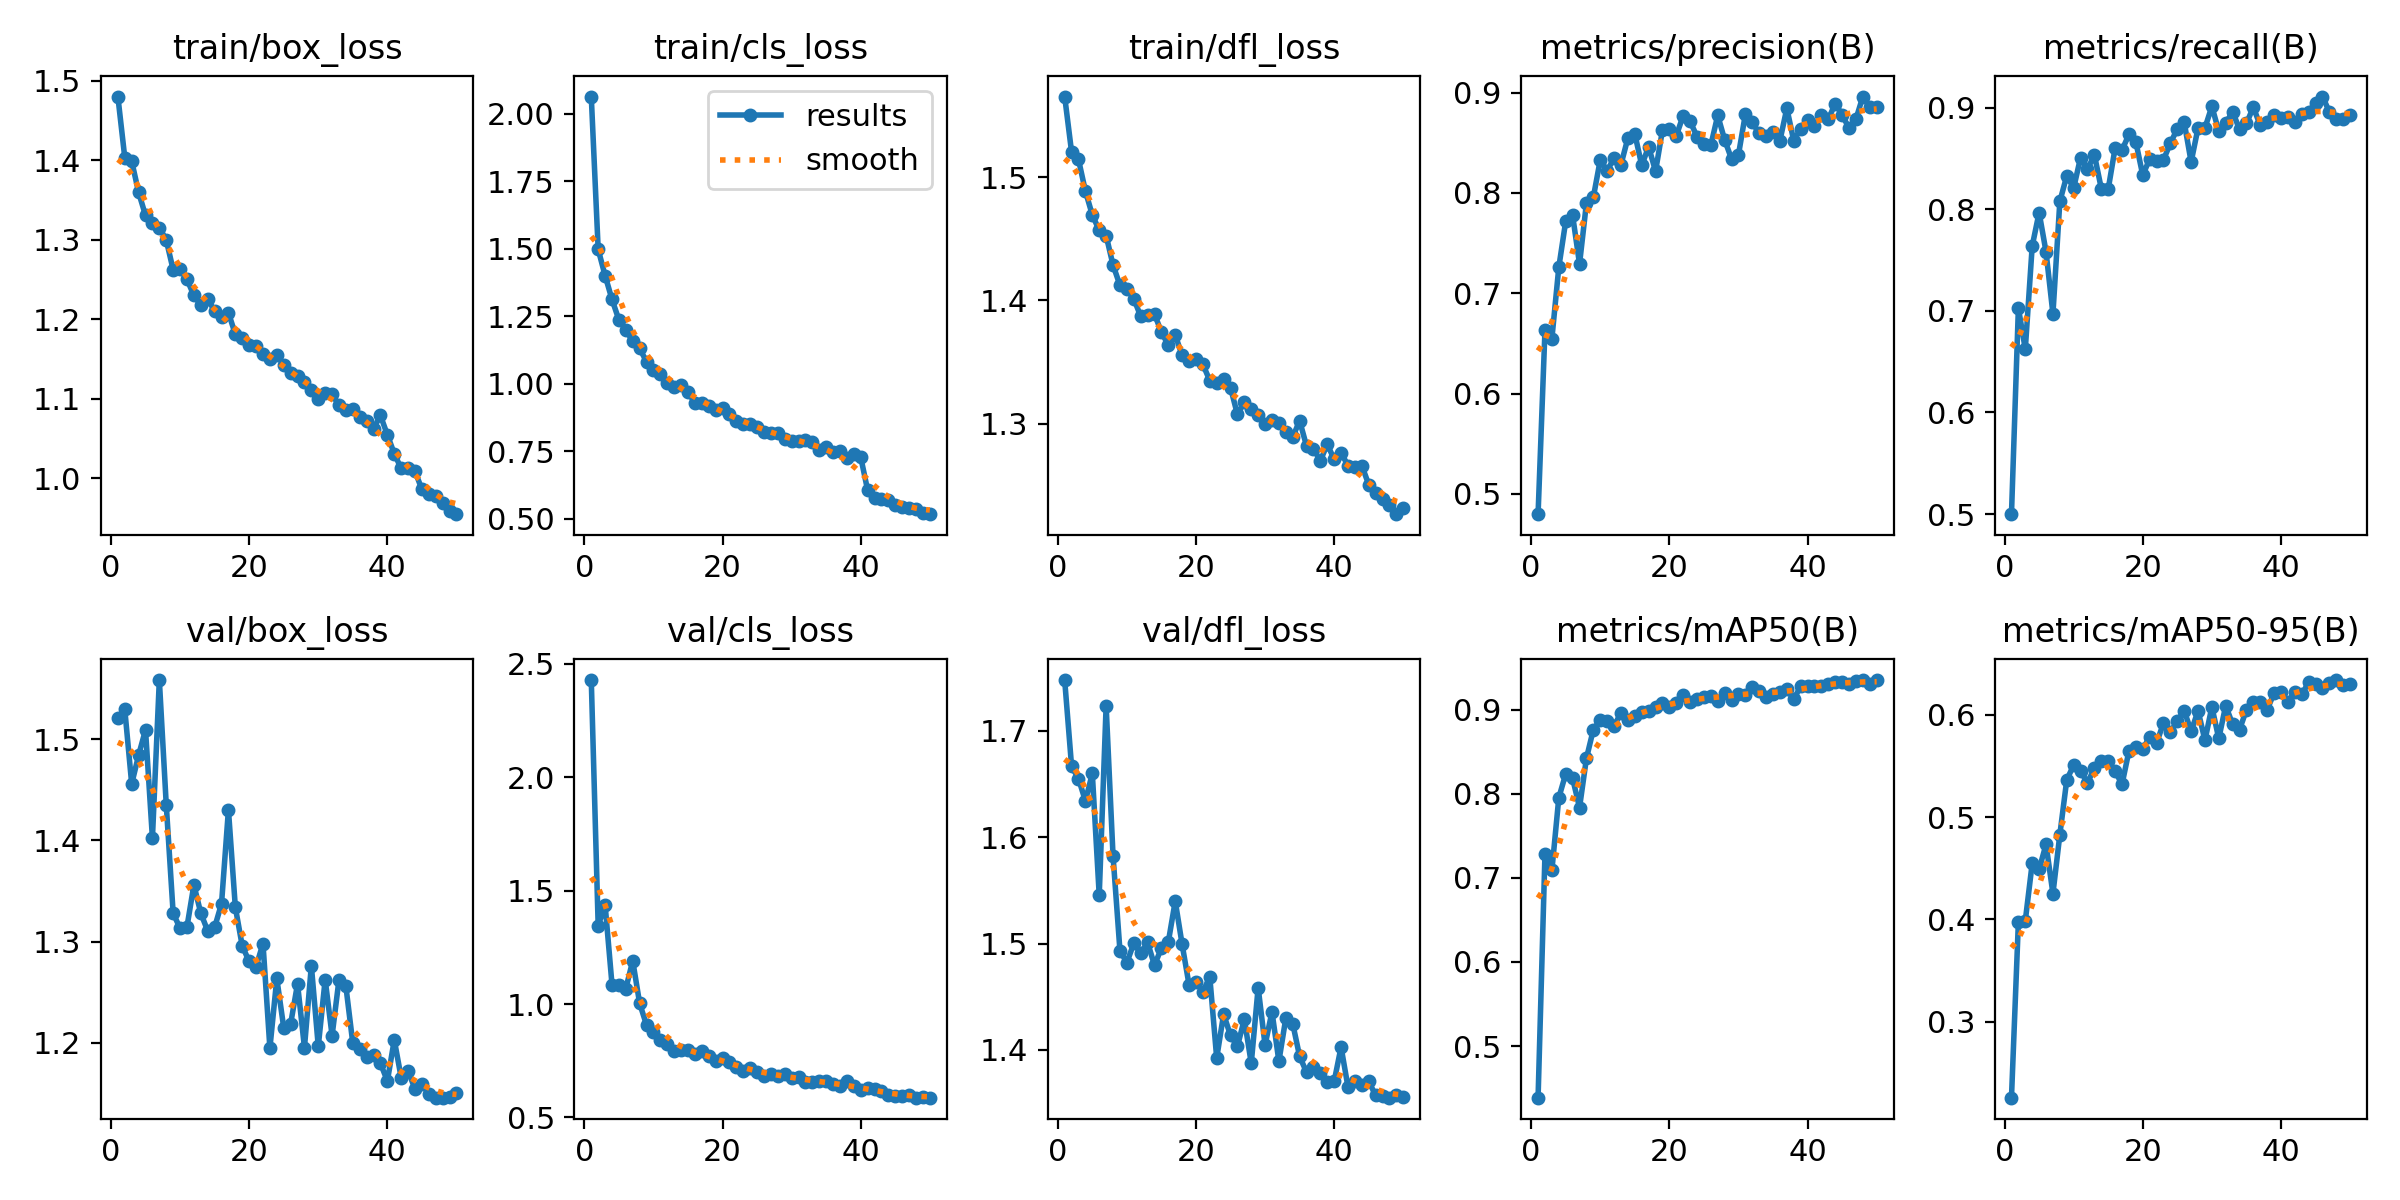

In [68]:
from IPython.display import Image

Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/results.png"
)

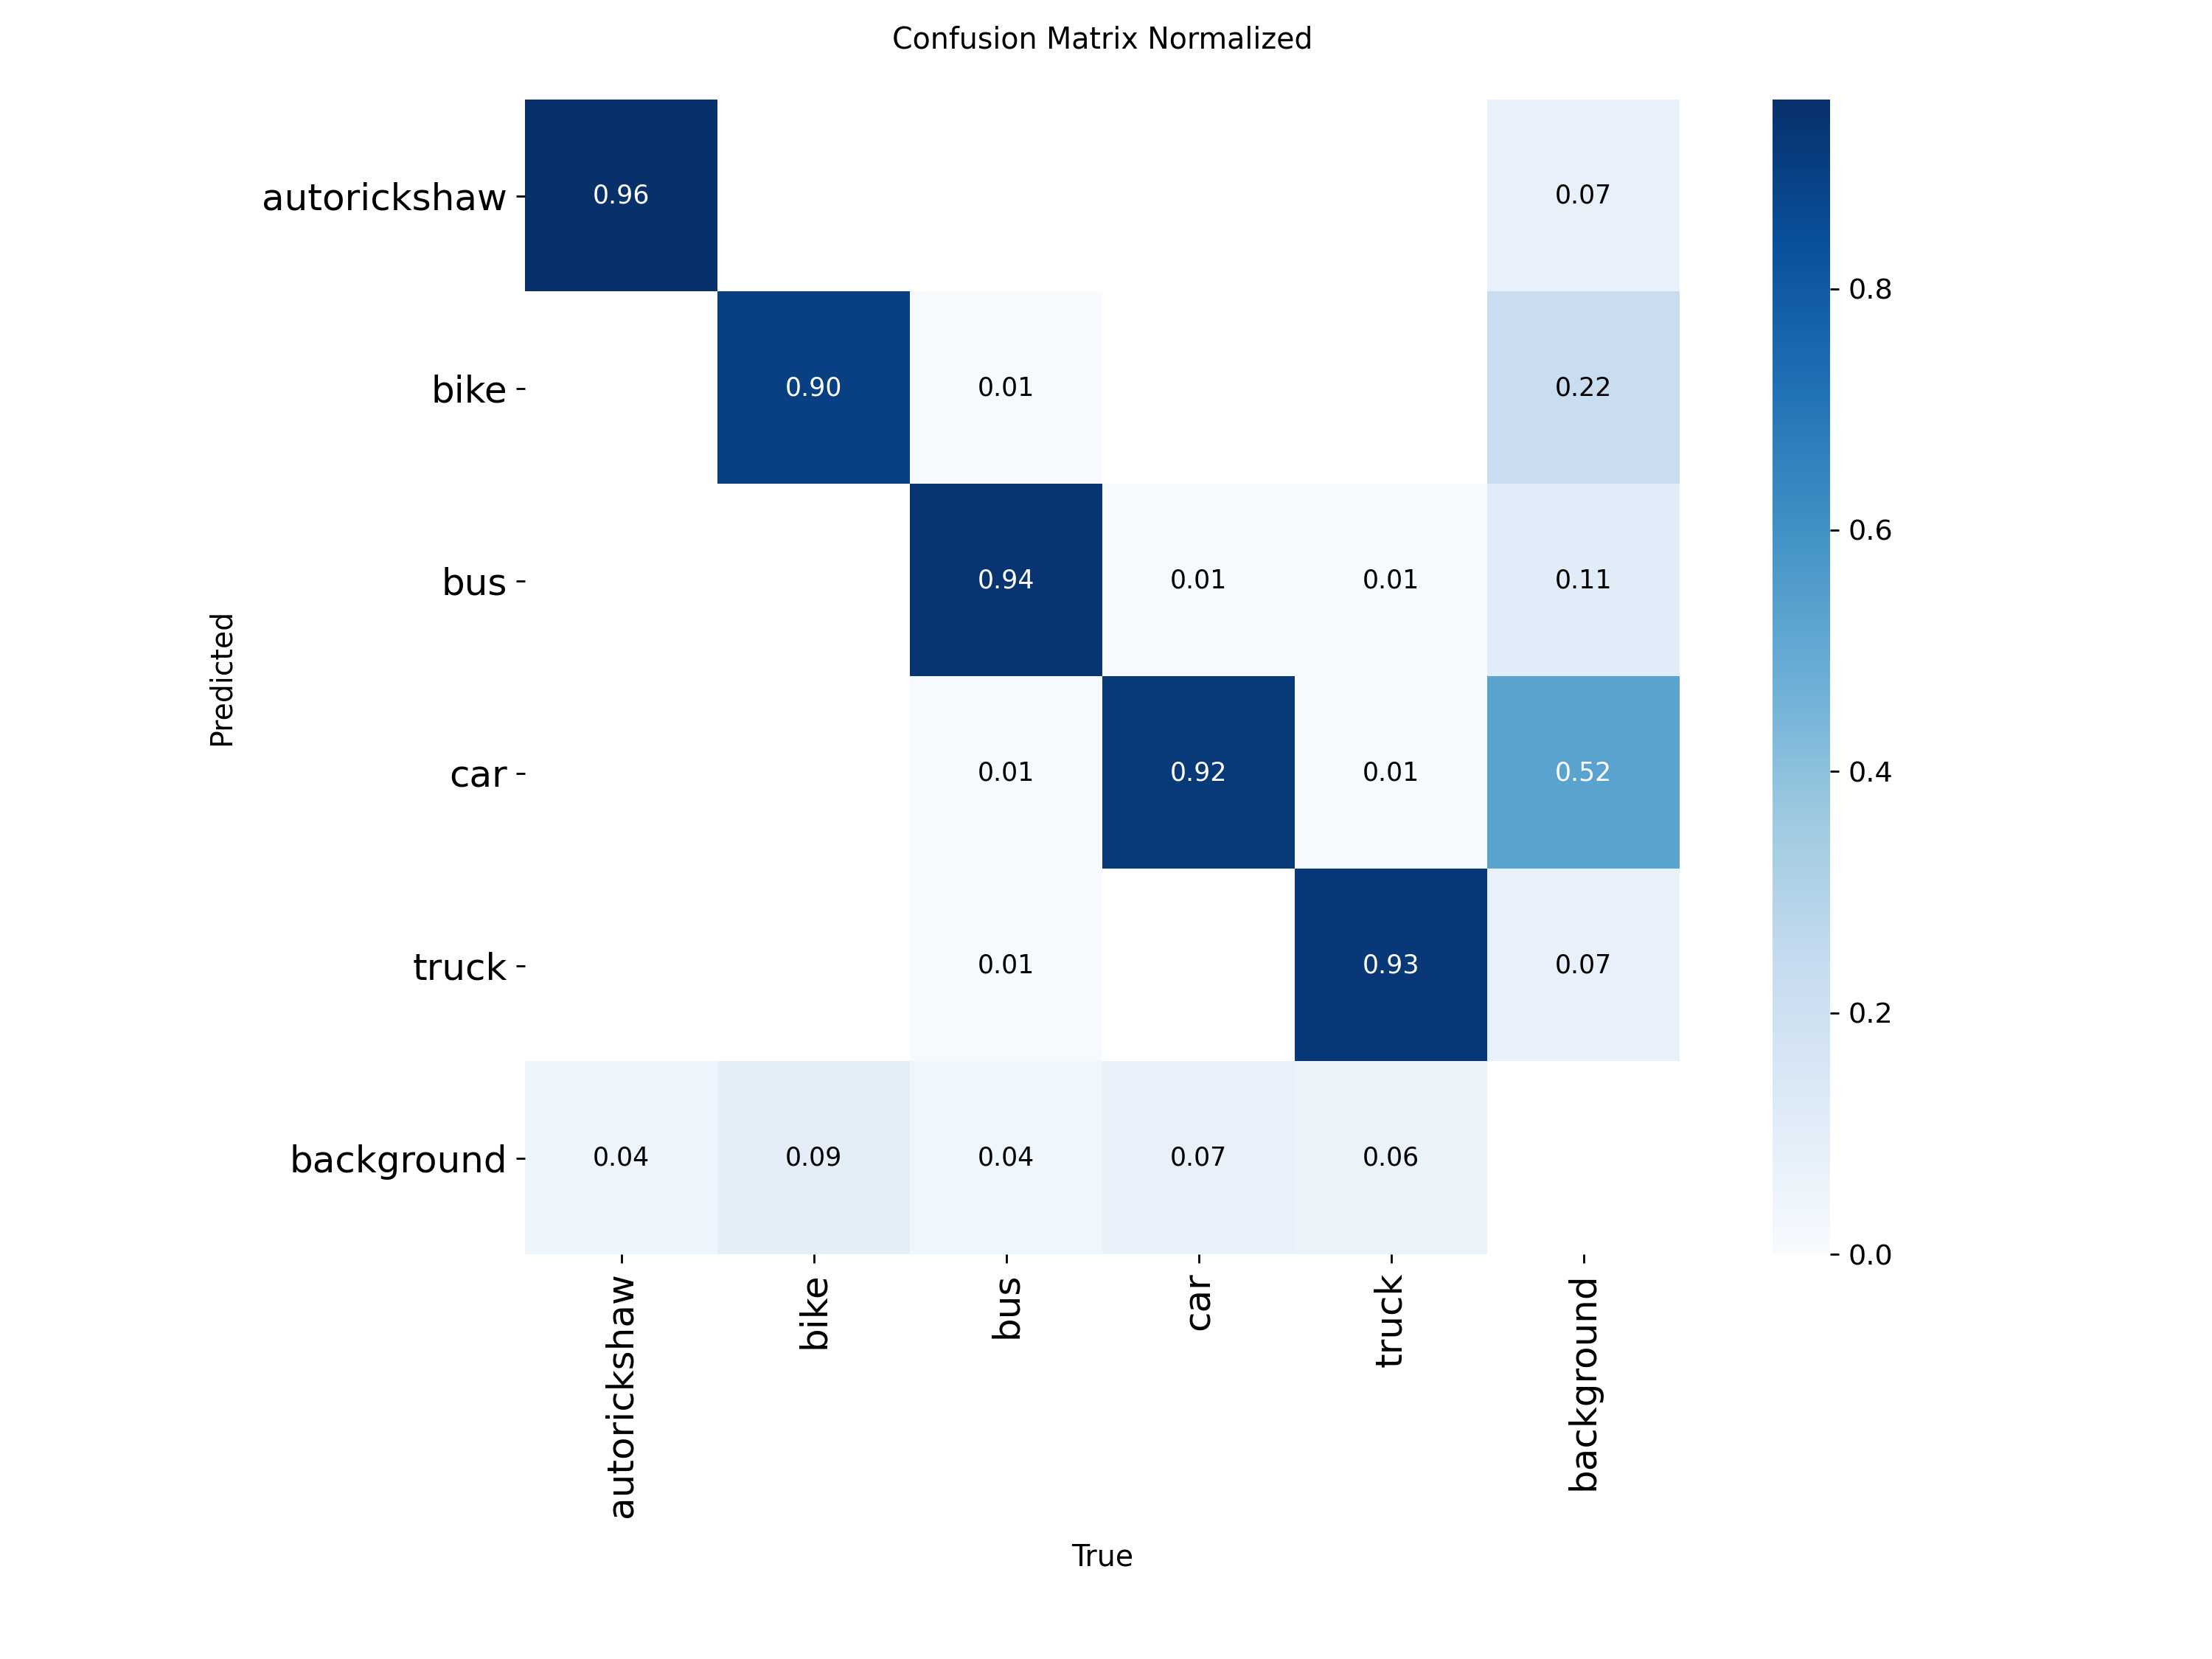

In [70]:
Image(
    filename="/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/confusion_matrix_normalized.png"
)

In [72]:
from ultralytics import YOLO

best_model = YOLO(
    "/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/weights/best.pt"
)


In [73]:
import random
import os

img_path = random.choice(
    os.listdir("/kaggle/working/vehicle_dataset/valid/images")
)

img_path = os.path.join(
    "/kaggle/working/vehicle_dataset/valid/images",
    img_path
)

print(img_path)

/kaggle/working/vehicle_dataset/valid/images/Bike_93_jpg.rf.ce80bf9c13fac3ae565737451e51b493.jpg


In [74]:
results = best_model.predict(
    source=img_path,
    conf=0.25,
    save=True,
    show_labels=True,
    show_conf=True
)


image 1/1 /kaggle/working/vehicle_dataset/valid/images/Bike_93_jpg.rf.ce80bf9c13fac3ae565737451e51b493.jpg: 640x640 1 bike, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


In [75]:
import os

for root, dirs, files in os.walk("/kaggle/working/runs/detect"):
    print(root)

/kaggle/working/runs/detect
/kaggle/working/runs/detect/Indian_Vehicle_Detection
/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom
/kaggle/working/runs/detect/Indian_Vehicle_Detection/YOLOv8n_Custom/weights
/kaggle/working/runs/detect/predict


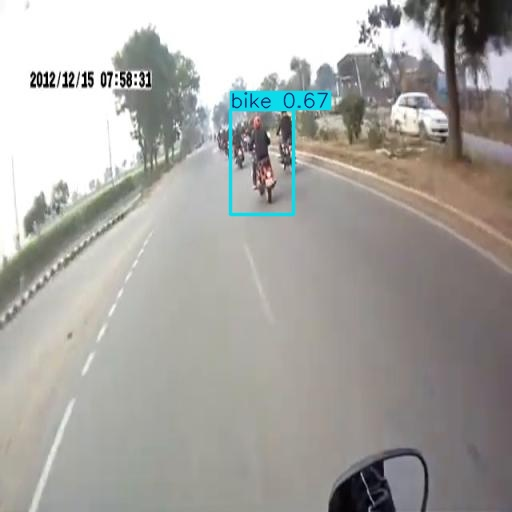

In [110]:
from IPython.display import Image

Image(
    filename="/kaggle/working/runs/detect/predict/Bike_93_jpg.rf.ce80bf9c13fac3ae565737451e51b493.jpg"
)

In [ ]:
import os

VIDEO_FOLDER = "/kaggle/input/datasets/tanya24jain/real-world-unseen-traffic-video-dataset/unseen_test_videos"

videos = sorted(os.listdir(VIDEO_FOLDER))

print("Total Videos:", len(videos))
for i, v in enumerate(videos):
    print(i+1, v)

In [141]:
import os

VIDEO_FOLDER = "/kaggle/input/datasets/tanya24jain/real-world-unseen-traffic-video-dataset/unseen_test_videos"

videos = sorted(os.listdir(VIDEO_FOLDER))

print("Total Videos:", len(videos))
for i, v in enumerate(videos):
    print(i+1, v)

Total Videos: 18
1 istockphoto-1095559474-640_adpp_is.mp4
2 istockphoto-1167761682-640_adpp_is.mp4
3 istockphoto-1172628115-640_adpp_is (1).mp4
4 istockphoto-1172628115-640_adpp_is.mp4
5 istockphoto-1266433944-640_adpp_is.mp4
6 istockphoto-1385480135-640_adpp_is.mp4
7 istockphoto-1385487163-640_adpp_is.mp4
8 istockphoto-1425716308-640_adpp_is.mp4
9 istockphoto-1900366764-640_adpp_is.mp4
10 istockphoto-1903006249-640_adpp_is.mp4
11 istockphoto-2151679057-640_adpp_is.mp4
12 istockphoto-2169685941-640_adpp_is.mp4
13 istockphoto-2193558699-640_adpp_is.mp4
14 istockphoto-2227097144-640_adpp_is.mp4
15 istockphoto-2230626901-640_adpp_is.mp4
16 istockphoto-2258979804-640_adpp_is.mp4
17 istockphoto-2278267406-640_adpp_is.mp4
18 istockphoto-543255860-640_adpp_is.mp4


In [142]:
import os

VIDEO_PATH = os.path.join(VIDEO_FOLDER, videos[0])

print("Selected Video:", VIDEO_PATH)
print("Exists:", os.path.exists(VIDEO_PATH))

Selected Video: /kaggle/input/datasets/tanya24jain/real-world-unseen-traffic-video-dataset/unseen_test_videos/istockphoto-1095559474-640_adpp_is.mp4
Exists: True


In [143]:
import cv2

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS:", fps)
print("Frames:", frames)
print("Resolution:", w, "x", h)

cap.release()

FPS: 29.97002997002997
Frames: 269
Resolution: 768 x 432


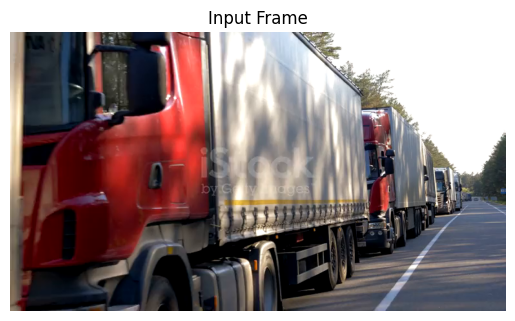

In [144]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame)
    plt.title("Input Frame")
    plt.axis("off")
    plt.show()

cap.release()

In [160]:
import cv2

cap = cv2.VideoCapture(VIDEO_PATH)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0:
    fps = 20

w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "/kaggle/working/output_result.mp4",
    fourcc,
    fps,
    (w, h)
)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = best_model(frame, conf=0.25, verbose=False)

    annotated_frame = results[0].plot()

    out.write(annotated_frame)

cap.release()
out.release()

Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to /kaggle/working/runs/detect/predict/labels
Results saved to /kaggle/working/runs/detect/predict
285 labels saved to

In [161]:
from IPython.display import HTML

HTML("""
<video width="800" height="400" controls>
  <source src="/kaggle/working/output_result.mp4" type="video/mp4">
</video>
""")